# Last Modified: 2026-04-23 15:00:00

---

# LFP Battery SOH Preprocessing Pipeline (Universal Version)

This notebook implements a physically-consistent preprocessing framework for multi-source battery datasets:
1. **Phase 0**: Data Loading (HUST, MIT-Stanford, etc.)
2. **Phase 0-1**: MIT Data Adapter (Port to HUST DataFrame Format)
3. **Phase 0.5**: Dataset-agnostic Configuration & Helpers
4. **Phase 1**: Global Physical Cleaning (Savitzky-Golay Smoothing & Outlier Removal)
5. **Phase 2**: Scenario-based Slicing Definition
6. **Phase 2.1**: **Global Slicing Loop (Generate & Cache Raw Segment Pool with RUL/Cap labels)**
7. **Phase 3**: 45D Adaptive HI Extraction Logic (Standardized V/I/T/Q features)
8. **Phase 4**: **Feature Extraction & Batch Scaling**
9. **Phase 5**: Global Tensor Saving (Optimized pkl tensors on D: drive)
10. **Phase 6**: Dataset-wide Visualization & PCA Analysis

In [1]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from tqdm.notebook import tqdm
import os
import sys
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
from scipy.signal import savgol_filter
from collections import defaultdict
import random

from datetime import date

# 오늘 날짜 객체 생성 
today = date.today()

figure_path = Path(f"../../outputs/figures/{today.strftime('%m%d')}")
figure_path.mkdir(parents=True, exist_ok=True)

# Add project root to sys.path
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Set processed data storage path (D drive for large files)
PROCESSED_DATA_ROOT = Path("D:/chanminLee/data_store/LFP_SOH_estimation")
PROCESSED_DATA_ROOT.mkdir(parents=True, exist_ok=True)

from src.data.loaders import load_hust, load_mit, calc_Q

## Phase 0: Data Loading

In [2]:
DATASET_TYPE = "hust" # Switch to "hust" or "mit" as needed

# --- [1. Pipeline Control] ---
# 1: Physical Cleaning, 2: Slicing, 3: Feature Extraction, 4: Final Tensor Saving
START_PHASE = 4 
FORCE_REGEN = False 

# --- [2. Global Path Management] ---
PROJECT_ROOT = Path.cwd().parent.parent
PROCESSED_DATA_ROOT = Path("D:/chanminLee/data_store/LFP_SOH_estimation")
FIGURE_ROOT = PROJECT_ROOT / "outputs" / "figures" / date.today().strftime('%m%d')

# Phase 1: Physical Cleaning
CLEAN_CACHE_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_clean_chunks"
CLEAN_REPORT_PATH = PROJECT_ROOT / "outputs" / f"{DATASET_TYPE}_cleaning_report.csv"

# Phase 2: Scenario-based Slicing
CACHE_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_sliced_chunks"

# Phase 3: Feature Extraction & Scaling
FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_feature_batches"
SCALER_CACHE_PATH = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_scaler.pkl"

# Phase 4: Final Tensor Saving
FINAL_TENSOR_PATH = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_optimized_tensors.pkl"

# Ensure all directories exist
for p in [PROCESSED_DATA_ROOT, FIGURE_ROOT, CLEAN_CACHE_DIR, CACHE_DIR, FEATURE_BATCH_DIR, PROCESSED_DATA_ROOT / DATASET_TYPE]:
    p.mkdir(parents=True, exist_ok=True)

In [3]:
if DATASET_TYPE == "hust":
    print("Loading HUST dataset...")
    all_cells = load_hust(PROJECT_ROOT / "HUST_data" / "data")
elif DATASET_TYPE == "mit":
    print("Loading MIT-Stanford dataset...")
    all_cells = load_mit(PROJECT_ROOT / "MIT_data")
print(f"Loaded {len(all_cells)} cells for {DATASET_TYPE.upper()} dataset.")

Loading HUST dataset...


HUST Cells:   0%|          | 0/77 [00:00<?, ?it/s]

Loaded 77 cells for HUST dataset.


In [4]:
os.makedirs(PROCESSED_DATA_ROOT / f"{DATASET_TYPE}", exist_ok=True)

if DATASET_TYPE == "mit":
    # sample_cell = next(iter(all_cells.values()))
    # Basic EDA: Check column availability and data quality
    print("\n=== Basic EDA ===")
    sample_cid = list(all_cells.keys())[0]
    sample_cell = all_cells[sample_cid]
    print(f"Sample Cell ID: {sample_cid}")
    print(f"Available columns: {sample_cell.__dict__.keys()}")
    print(f"Available summary columns: {sample_cell.summary.keys()}")
    print(f"Available cycles columns: {sample_cell.cycles.keys()}")
    print(f"Available cycle 1 columns: {sample_cell.cycles['1'].keys()}")
    print(f"summary data each columns length: { {k: len(v) for k, v in sample_cell.summary.items()} }")
    print(f":{sample_cell.summary}")

    cycle_dict = sample_cell.cycles['1']
    cycle_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in cycle_dict.items()]))

    pd.DataFrame(sample_cell.summary).to_csv(PROCESSED_DATA_ROOT / f"mit/{sample_cid}_summary.csv", index=False) # Save raw data for inspection   
    pd.DataFrame(cycle_df).to_csv(PROCESSED_DATA_ROOT / f"mit/{sample_cid}_cycles.csv", index=False) # Save raw data for inspection   

elif "hust":
    # sample_cell = next(iter(all_cells.values()))
    # Basic EDA: Check column availability and data quality
    print("\n=== Basic EDA ===")
    sample_cid = list(all_cells.keys())[0]
    sample_cell = all_cells[sample_cid]
    print(f"Sample Cell ID: {sample_cid}")
    print(f"Available columns: {sample_cell.__dict__.keys()}")
    print(f'dq columns: {sample_cell.dq}') # mAh 단위 
    print(f'data columns: {sample_cell.data[1]}') 
    sample_cell.data[1].to_csv(PROCESSED_DATA_ROOT / f"hust/{sample_cid}_raw.csv", index=False) # Save raw data for inspection


=== Basic EDA ===
Sample Cell ID: 1-1
Available columns: dict_keys(['cell_id', 'batch_id', 'rul', 'dq', 'data'])
dq columns: {1: 1174.2992, 2: 1173.1189555555557, 3: 1172.5066444444444, 4: 1171.9004222222222, 5: 1171.2945333333332, 6: 1171.2867111111111, 7: 1170.6743777777779, 8: 1170.6697111111112, 9: 1170.6636222222223, 10: 1170.0476666666666, 11: 1170.0405333333333, 12: 1169.4238, 13: 1169.414288888889, 14: 1169.4155333333333, 15: 1168.8119555555556, 16: 1168.8009777777777, 17: 1168.804688888889, 18: 1168.2006888888889, 19: 1168.195311111111, 20: 1168.202622222222, 21: 1167.5969333333333, 22: 1167.6103555555555, 23: 1167.5882888888889, 24: 1167.565, 25: 1167.5591333333332, 26: 1167.5221999999999, 27: 1166.8688222222222, 28: 1166.8834222222222, 29: 1166.8656222222223, 30: 1166.8665777777778, 31: 1166.2456444444447, 32: 1166.2467333333334, 33: 1166.2398, 34: 1166.2232, 35: 1166.235488888889, 36: 1166.2312444444444, 37: 1165.6056888888888, 38: 1165.592488888889, 39: 1165.5801111111111

In [5]:
print("\n=== Basic EDA & Sample Export ===")
sample_cid = list(all_cells.keys())[0]
sample_cell = all_cells[sample_cid]
print(f"Sample Cell ID: {sample_cid}")

if DATASET_TYPE == "mit":
    cycle_dict = sample_cell.cycles['1']
    cycle_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in cycle_dict.items()]))
    pd.DataFrame(sample_cell.summary).to_csv(PROCESSED_DATA_ROOT / f"{DATASET_TYPE}/{sample_cid}_summary.csv", index=False)
    pd.DataFrame(cycle_df).to_csv(PROCESSED_DATA_ROOT / f"{DATASET_TYPE}/{sample_cid}_cycles.csv", index=False)
elif DATASET_TYPE == "hust":
    sample_cell.data[1].to_csv(PROCESSED_DATA_ROOT / f"{DATASET_TYPE}/{sample_cid}_raw.csv", index=False)

# Define standardized column constants for internal logic
COL_V = "Voltage (V)"
COL_I = "Current (A)"
COL_T = "Temperature (°C)"
COL_TIME = "Time (s)"

def get_cell_labels(cell, cyc, dataset_type):
    """Extract RUL and SOH (Capacity) labels in a dataset-agnostic way."""
    if dataset_type == "hust":
        return cell.rul[cyc], cell.dq[cyc]/1000.0  # Convert mAh to Ah for consistency
    elif dataset_type == "mit":
        rul = (cell.cycle_life - cyc) if cell.cycle_life else 0
        cap = cell.summary['QD'][cyc-1] if (cyc-1) < len(cell.summary['QD']) else 0.0
        return float(rul), float(cap)
    return 0.0, 0.0

def get_batch_id(cid, dataset_type):
    """Standardize batch identification for grouping chunks."""
    if dataset_type == "hust":
        return str(cid).split("-")[0]
    elif dataset_type == "mit":
        return str(cid).split("c")[0]
    return "batch_0"


=== Basic EDA & Sample Export ===
Sample Cell ID: 1-1


## Phase 0-1: Data Adapter

In [6]:
if DATASET_TYPE == "mit":
    print("Porting MIT data to Unified DataFrame format...")
    for cid, cell in tqdm(all_cells.items(), desc="Converting MIT"):
        cell.data = {}
        for cyc_key, cyc_dict in cell.cycles.items():
            if int(cyc_key) > 0:
                q_total = np.where(cyc_dict['I'] >= 0, cyc_dict['Qc'], cyc_dict['Qd'])
                cell.data[int(cyc_key)] = pd.DataFrame({
                    COL_TIME: cyc_dict['t'], COL_V: cyc_dict['V'],
                    COL_I: cyc_dict['I'], COL_T: cyc_dict['T'], 'capacity': q_total
                })
elif DATASET_TYPE == "hust":
    print("Standardizing HUST data...")
    for cid, cell in tqdm(all_cells.items(), desc="Standardizing HUST"):
        for cyc in list(cell.data.keys()):
            df = cell.data[cyc].copy()
            if 'Capacity (mAh)' in df.columns: df['capacity'] = df['Capacity (mAh)'] / 1000.0
            if 'Current (mA)' in df.columns: df[COL_I] = df['Current (mA)'] / 1000.0
            rename_dict = {'Voltage (V)': COL_V, 'Temperature (degC)': COL_T, 'Time (s)': COL_TIME}
            cell.data[cyc] = df.rename(columns={k: v for k, v in rename_dict.items() if k in df.columns})

Standardizing HUST data...


Standardizing HUST:   0%|          | 0/77 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# --- Unified Data Structure Audit ---
print(f"=== 📊 {DATASET_TYPE.upper()} Unified Dataset Audit ===")
total_cells = len(all_cells)
cycle_counts = [len(cell.data) for cell in all_cells.values()]
print(f"1. Total Cells loaded: {total_cells}")
print(f"2. Cycle Stats per Cell: Min={np.min(cycle_counts)}, Max={np.max(cycle_counts)}, Avg={np.mean(cycle_counts):.1f}")

# Extract sample data for schema inspection
sample_cid = list(all_cells.keys())[0]
sample_cyc = list(all_cells[sample_cid].data.keys())[0]
sample_df = all_cells[sample_cid].data[sample_cyc]

print(f"\n3. Unified DataFrame Schema (Cell {sample_cid}, Cyc {sample_cyc}):")
print(f"   - Columns: {sample_df.columns.tolist()}")
print(f"   - Shape: {sample_df.shape}")
print(f"   - Data Types:\n{sample_df.dtypes}")

# Check for essential features for preprocessing
has_time = COL_TIME in sample_df.columns
has_v = COL_V in sample_df.columns
has_i = COL_I in sample_df.columns

print(f"\n4. Preprocessing Readiness Check:")
print(f"   - Time info available: {has_time}")
print(f"   - Voltage info available: {has_v}")
print(f"   - Current info available: {has_i}")

# sample data preview
print(f"\n5. Sample Data Preview (Cell {sample_cid}, Cyc {sample_cyc}):")
print(sample_df.head())
print(sample_df.tail(), '\n')
print(sample_df.describe())

if DATASET_TYPE == 'mit':
    print("   - [MIT Note] Current converted to Ampere (A) from loader.")
elif DATASET_TYPE == 'hust':
    print("   - [HUST Note] Voltage smoothing and Current unit conversion (mA->A) pending in Phase 1.")

print("===========================================")

=== 📊 MIT Unified Dataset Audit ===
1. Total Cells loaded: 135
2. Cycle Stats per Cell: Min=169, Max=2236, Avg=848.9

3. Unified DataFrame Schema (Cell b1c0, Cyc 1):
   - Columns: ['Time (s)', 'Voltage (V)', 'Current (A)', 'Temperature (°C)', 'capacity']
   - Shape: (1087, 5)
   - Data Types:
Time (s)            float64
Voltage (V)         float64
Current (A)         float64
Temperature (°C)    float64
capacity            float64
dtype: object

4. Preprocessing Readiness Check:
   - Time info available: True
   - Voltage info available: True
   - Current info available: True

5. Sample Data Preview (Cell b1c0, Cyc 1):
   Time (s)  Voltage (V)  Current (A)  Temperature (°C)  capacity
0  0.000000     2.026416     0.000000         31.632496  0.000000
1  0.002417     2.039388     0.215908         31.632496  0.000001
2  0.002912     2.051660     0.359831         31.632496  0.000001
3  0.003212     2.063070     0.467846         31.632496  0.000001
4  0.003498     2.076204     0.575877       

## Phase 1: Global Physical Cleaning

In [ ]:
def clean_physical_data(df, cid, cyc, cleaning_reports):
    clean_df = df.copy()
    # Standardize Current (ensure Amperes)
    if "Current (mA)" in clean_df.columns: clean_df[COL_I] = clean_df["Current (mA)"] / 1000.0
    elif clean_df[COL_I].abs().mean() > 50: clean_df[COL_I] = clean_df[COL_I] / 1000.0
        
    if 'capacity' not in clean_df.columns:
        q_c = calc_Q(clean_df[COL_I].values, clean_df[COL_TIME].values, is_charge=True)
        q_d = calc_Q(clean_df[COL_I].values, clean_df[COL_TIME].values, is_charge=False)
        clean_df['capacity'] = np.where(clean_df[COL_I] >= 0, q_c, q_d)
    
    num_cols = clean_df.select_dtypes(include=[np.number]).columns
    outlier_mask = pd.Series(False, index=clean_df.index)
    detail_records = {}
    for col in num_cols:
        if col == COL_V and DATASET_TYPE == "hust": continue
        details = {'outlier_info': [], 'nan_info': []}
        nan_mask = clean_df[col].isna()
        if nan_mask.any(): details['nan_info'] = clean_df.index[nan_mask].tolist()
        col_std = clean_df[col].std()
        if col_std > 1e-6:
            z_scores = np.abs((clean_df[col] - clean_df[col].mean()) / col_std)
            is_outlier = z_scores >= 10
            if is_outlier.any():
                outlier_mask |= is_outlier
                details['outlier_info'] = [(idx, round(val, 4)) for idx, val in zip(clean_df.index[is_outlier], clean_df.loc[is_outlier, col])]
        detail_records[col] = details
        
    if outlier_mask.any(): clean_df = clean_df[~outlier_mask].copy()
    if not clean_df.empty:
        for col in num_cols:
            det = detail_records[col]
            o_count, nan_count = len(det['outlier_info']), len(det['nan_info'])
            if o_count > 0 or nan_count > 0:
                cleaning_reports.append({
                    "cell_id": cid, "cycle": cyc, "feature": col,
                    "outlier_removed": o_count, "interpolated_count": nan_count,
                    "outlier_details_(idx,val)": str(det['outlier_info']) if o_count > 0 else "",
                    "nan_indices": str(det['nan_info']) if nan_count > 0 else ""
                })
        clean_df[num_cols] = clean_df[num_cols].interpolate(method='linear', limit_direction='both')
        clean_df = clean_df.ffill().bfill()
        if COL_V in clean_df.columns and len(clean_df) >= 11:
            clean_df[COL_V] = savgol_filter(clean_df[COL_V], window_length=11, polyorder=3)
    return clean_df

if START_PHASE <= 1 or not (CLEAN_CACHE_DIR / f"batch_clean_b1.pkl").exists():
    print(f"[Phase 1] Starting Physical Cleaning for {DATASET_TYPE}...")
    batch_groups = defaultdict(dict)
    for cid, cell in all_cells.items():
        b_id = get_batch_id(cid, DATASET_TYPE)
        batch_groups[b_id][cid] = cell
    all_cleaning_reports = []
    for batch_id in sorted(batch_groups.keys()):
        batch_cache_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}.pkl"
        if batch_cache_path.exists() and not FORCE_REGEN:
            report_part_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}_report.pkl"
            if report_part_path.exists():
                with open(report_part_path, "rb") as f: all_cleaning_reports.extend(pickle.load(f))
            continue
        batch_cells = batch_groups[batch_id]
        batch_cleaned, batch_reports = {}, []
        for cid, cell in batch_cells.items():
            batch_cleaned[cid] = {}
            for cyc in tqdm(list(cell.data.keys()), desc=f"  Cleaning Cell {cid}", leave=False):
                batch_cleaned[cid][cyc] = clean_physical_data(cell.data[cyc], cid, cyc, batch_reports)
        with open(batch_cache_path, "wb") as f: pickle.dump(batch_cleaned, f, protocol=pickle.HIGHEST_PROTOCOL)
        report_part_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}_report.pkl"
        with open(report_part_path, "wb") as f: pickle.dump(batch_reports, f, protocol=pickle.HIGHEST_PROTOCOL)
        all_cleaning_reports.extend(batch_reports)
        del batch_cleaned, batch_reports; gc.collect()
    pd.DataFrame(all_cleaning_reports).to_csv(CLEAN_REPORT_PATH, index=False)
else:
    print(f"[Phase 1] Skipping Physical Cleaning. Using existing cache.")

[Phase 1] Skipping Physical Cleaning. Using existing cache.


### 이상치 csv 시각화

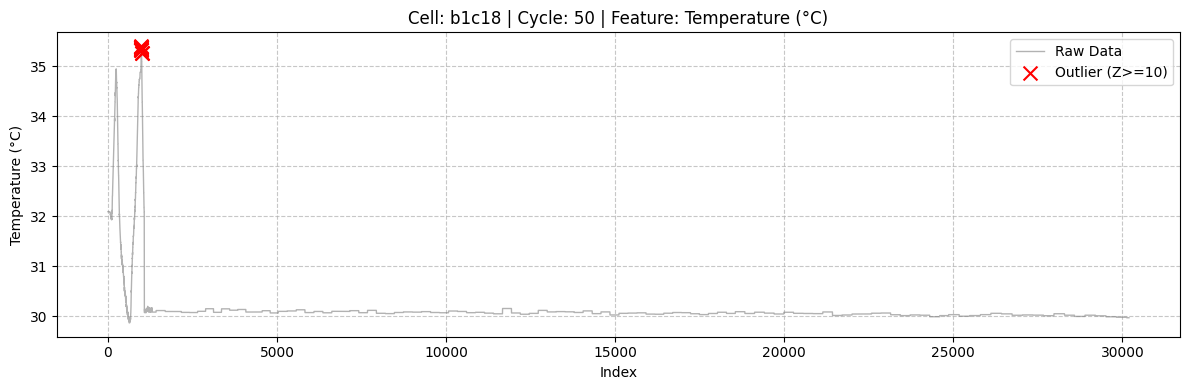

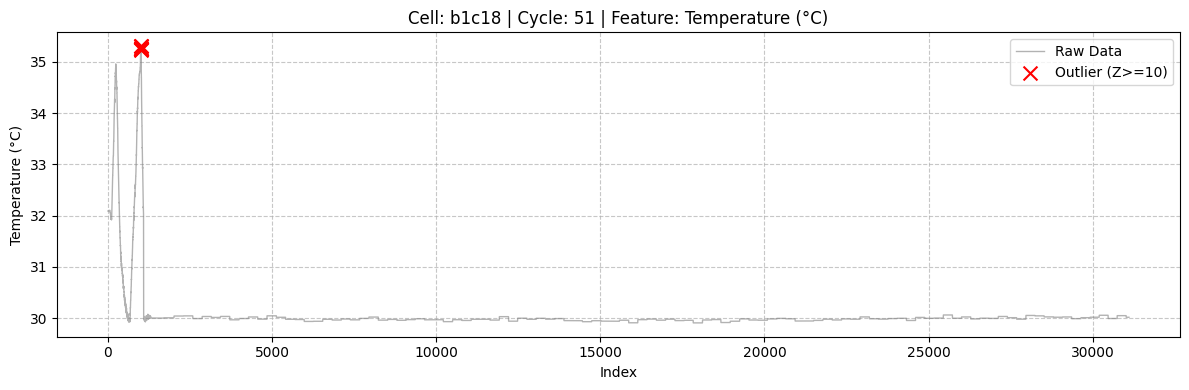

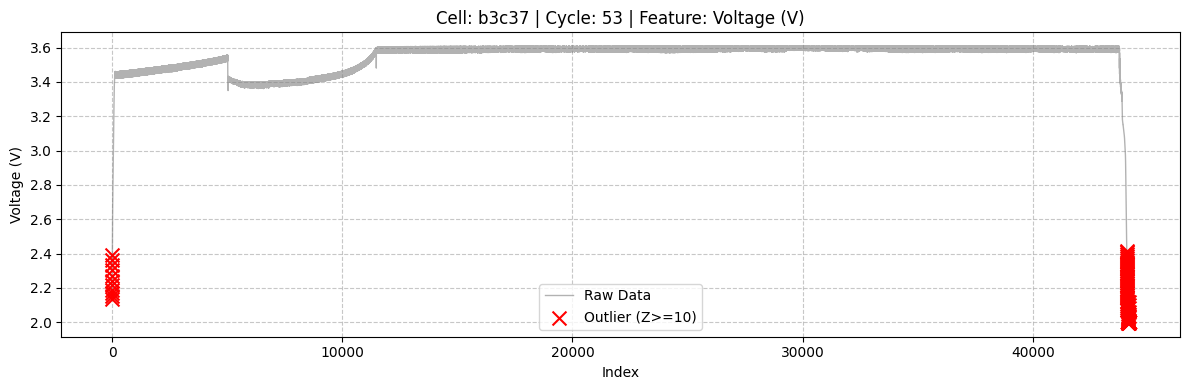

In [ ]:
import matplotlib.pyplot as plt

outlier_threshold = 10

def plot_data_cleaning_issues(all_cells, report_df, num_samples=5):
    """
    이상치나 결측치가 보고된 셀/사이클 데이터를 시각화합니다.
    """
    if report_df.empty:
        print("보고된 이상치/결측치가 없습니다.")
        return

    # 유니크한 (cell_id, cycle) 조합 중 상위 n개 선택
    samples = report_df[['cell_id', 'cycle']].drop_duplicates().head(num_samples)
    
    for _, row in samples.iterrows():
        cid = row['cell_id']
        cyc = row['cycle']

        # 해당 셀과 사이클의 원본 데이터 가져오기
        if cid not in all_cells or cyc not in all_cells[cid].data:
            continue

        raw_df = all_cells[cid].data[cyc].copy()

        # mA -> A 변환 (원본 데이터가 mA인 경우 대비)
        if "Current (mA)" in raw_df.columns and COL_I not in raw_df.columns:
            raw_df[COL_I] = raw_df["Current (mA)"] / 1000.0

        # 해당 (cid, cyc)에 대해 보고된 모든 피처들 확인
        issues = report_df[(report_df['cell_id'] == cid) & (report_df['cycle'] == cyc)]

        fig, axes = plt.subplots(len(issues), 1, figsize=(12, 4 * len(issues)), sharex=True)
        if len(issues) == 1:
            axes = [axes]

        for ax, (_, issue) in zip(axes, issues.iterrows()):
            col = issue['feature']

            # 1. 전체 데이터 플롯
            ax.plot(raw_df.index, raw_df[col], label='Raw Data', color='gray', alpha=0.6, linewidth=1)

            # 2. 결측치(NaN) 위치 표시
            nan_indices = raw_df.index[raw_df[col].isna()]
            if not nan_indices.empty:
                ax.scatter(
                    nan_indices,
                    [raw_df[col].mean()] * len(nan_indices),
                    marker='x',
                    color='blue',
                    s=100,
                    label='NaN (Missing)',
                    zorder=5
                )

            # 3. 이상치(Outlier) 위치 표시
            col_std = raw_df[col].std()
            if col_std > 1e-6:
                z_scores = np.abs((raw_df[col] - raw_df[col].mean()) / col_std)
                outlier_mask = z_scores >= outlier_threshold
                outlier_indices = raw_df.index[outlier_mask]

                if not outlier_indices.empty:
                    ax.scatter(
                        outlier_indices,
                        raw_df.loc[outlier_mask, col],
                        marker='x',
                        color='red',
                        s=100,
                        label=f'Outlier (Z>={outlier_threshold})',
                        zorder=6
                    )

            ax.set_title(f"Cell: {cid} | Cycle: {cyc} | Feature: {col}")
            # ax.set_xlabel(f"Index": {})
            ax.set_ylabel(col)
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.7)

        plt.xlabel("Index")
        plt.tight_layout()
        os.makedirs(figure_path / f"{DATASET_TYPE}", exist_ok=True)
        plt.savefig(figure_path / f"{DATASET_TYPE}" / f"cleaning_issues_{cid}_cycle{cyc}.png", dpi=300, bbox_inches='tight')
        plt.show()

# 사용 예시:
# import pdb; pdb.set_trace()
if (CLEAN_REPORT_PATH).exists():
    report_df = pd.read_csv(CLEAN_REPORT_PATH)
    plot_data_cleaning_issues(all_cells, report_df, num_samples=3)

### 전류적산 - capacity features 

In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def check_capacity_consistency(all_cells, dataset_type="hust"):
    """
    메타데이터의 용량(Q)과 전류 적산 기반 용량(Integrated Q)을 비교 분석합니다.
    """
    results = []
    
    for cid, cell in tqdm(all_cells.items(), desc=f"Verifying {dataset_type.upper()} Capacity"):
        # 사이클 목록 가져오기
        cycs = sorted(cell.data.keys()) if dataset_type == "hust" else sorted([int(k) for k in cell.cycles.keys() if int(k) > 0])

        for cyc in cycs:
            # 1. 원본 메타데이터 용량 가져오기
            if dataset_type == "hust":
                summary_q = cell.dq.get(cyc, 0.0)
                df = cell.data[cyc]
            else:  # mit
                if cyc == 0:
                    continue
                
                summary_q = cell.summary['QD'][cyc-1] if (cyc-1) < len(cell.summary['QD']) else 0.0

                # 1. 'lin'이 포함된 가공 피처 및 dQdV 제외
                exclude_keys = ['Qdlin', 'Tdlin', 'dQdV']
                cycle_dict = {k: v for k, v in cell.cycles[str(cyc)].items() if k not in exclude_keys}

                df = pd.DataFrame({k: v for k, v in cycle_dict.items()})

            if summary_q <= 0:
                continue
            
            integrated_q = None

            if dataset_type == "hust":
                # 2. 전류 적산(Coulomb Counting) 계산
                t = df['Time (s)'].values
                dt = np.diff(t, prepend=t[0])
                current = df['Current (A)'].values / 1000.0 if dataset_type == "hust" else df['I'].values  

                # 방전 구간(I < 0)만 추출
                dis_mask = current < -0.0001
                integrated_q = np.sum(np.abs(current[dis_mask]) * dt[dis_mask]) / 3600.0
        
            else:

                # 2. 전류 적산(Coulomb Counting) 계산
                t = df['t'].values
                dt = np.diff(t, prepend=t[0])
                current = df['I'].values / 1000.0 if dataset_type == "hust" else df['I'].values  

                # 방전 구간(I < 0)만 추출
                dis_mask = current < -0.0001
                integrated_q = np.sum(np.abs(current[dis_mask]) * dt[dis_mask]) / 3600.0

            # 3. 오차 계산
            abs_err = abs(summary_q - integrated_q)
            rel_err = (abs_err / summary_q) * 100 if summary_q > 0 else 0

            results.append({
                "cell_id": cid,
                "cycle": cyc,
                "summary_q": summary_q,
                "integrated_q": integrated_q,
                "abs_err_ah": abs_err,
                "rel_err_pct": rel_err
            })

    report_df = pd.DataFrame(results)

    if not report_df.empty:
        print(f"\n=== {dataset_type.upper()} Capacity Consistency Report ===")

        print(f"Total Cycles Verified: {len(report_df)}")
        print(f"Mean Absolute Error: {report_df['abs_err_ah'].mean():.4f} Ah")
        print(f"Max Absolute Error : {report_df['abs_err_ah'].max():.4f} Ah")
        print(f"Mean Relative Error: {report_df['rel_err_pct'].mean():.2f} %")

        # 오차율이 5% 이상인 심각한 사이클 확인
        critical = report_df[report_df['rel_err_pct'] > 5.0]
        if not critical.empty:
            print(f"Critical Anomalies (>5% error): {len(critical)} cycles found.")
            print(critical[['cell_id', 'cycle', 'summary_q', 'integrated_q', 'rel_err_pct']].head(10))
    else:
        print("No valid data found to compare.")

    report_df.to_csv(PROCESSED_DATA_ROOT / f"{dataset_type}_capacity_consistency_report.csv", index=False)
    
    return report_df

# 실행 예시
if START_PHASE <= 1:
    cap_report = check_capacity_consistency(all_cells, DATASET_TYPE)

## Phase 2: Scenario-based Slicing Definition

In [ ]:
def phase2_slice_data(df, start_p=0.0, end_p=1.0, mode="C", target_q=1.1): 
    col_i = COL_I if COL_I in df.columns else [c for c in df.columns if "Current" in c][0]
    col_t = COL_TIME
    
    # 1. Select data for the mode (Charge or Discharge)
    mode_df = df[df[col_i] > 0.01].copy() if mode == "C" else df[df[col_i] < -0.01].copy()
    if mode_df.empty: return mode_df, 0, (1 if mode == "C" else 0)
    
    # 2. Calculate relative accumulated capacity (Ah) for this specific phase
    # Both MIT (Qc/Qd) and HUST (mAh) have been unified into Ah in Phase 0-1/1
    if 'capacity' in mode_df.columns:
        # Reseting to 0 at the start of this mode's segment
        q_acc = (mode_df['capacity'] - mode_df['capacity'].iloc[0]).abs()
    else:
        # Final fallback integration
        dt = mode_df[col_t].diff().fillna(0)
        dq = (mode_df[col_i].abs() * dt) / 3600.0
        q_acc = dq.cumsum()
        
    # 3. Calculate capacity ratio relative to current cycle's capacity (target_q)
    q_ratio = q_acc / (target_q + 1e-9)
    q_ratio = np.clip(q_ratio, 0.0, 1.05)
    
    # 4. Slicing based on capacity bounds (start_p, end_p are ratios 0~1)
    mask = (q_ratio >= start_p) & (q_ratio <= end_p)
    sliced = mode_df[mask]
    
    # 5. Labeling based on User Requirement:
    # High (H): 100-70% SOC -> 0-0.3 cumulative discharge -> label -2
    # Mid (M): 70-30% SOC -> 0.3-0.7 cumulative discharge -> label -1
    # Low (L): 30-0% SOC -> 0.7-1.0 cumulative discharge -> label 0
    avg_pos = (start_p + end_p) / 2
    soc_label = -2 if avg_pos <= 0.3 else (-1 if avg_pos <= 0.7 else 0)
    mode_label = 1 if mode == "C" else 0

    # import pdb; pdb.set_trace()
    
    return sliced, soc_label, mode_label

## Phase 2.1: Global Slicing Loop

In [18]:
FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_feature_batches"
FEATURE_BATCH_DIR.mkdir(parents=True, exist_ok=True)
SCALER_CACHE_PATH = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_scaler.pkl"

# Robust check for any existing final batches
final_batch_files = sorted(FEATURE_BATCH_DIR.glob("final_*.pkl"))

if START_PHASE <= 3 or not final_batch_files:
    SKIP_PHASE_3 = False
    print(f"[Phase 3] Starting Feature Extraction (45D HI) for {DATASET_TYPE}...")
else:
    SKIP_PHASE_3 = True
    print(f"[Phase 3] Skipping. Loading {len(final_batch_files)} batches from cache for compatibility...")
    batch_feature_pool = []
    for bf in tqdm(final_batch_files, desc="Loading cached features"): 
        with open(bf, "rb") as f: batch_feature_pool.extend(pickle.load(f))


[Phase 3] Skipping. Loading 10 batches from cache for compatibility...


Loading cached features:   0%|          | 0/10 [00:00<?, ?it/s]

In [20]:
CACHE_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_sliced_chunks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
scen_bounds = {"H": (0.0, 0.3), "M": (0.3, 0.7), "L": (0.7, 1.0)}
lengths = [0.2, 0.3, 0.4]
step = 0.1

In [23]:
all_raw_segments = []
batch_groups = defaultdict(dict)

if DATASET_TYPE == "mit" and START_PHASE >= 3 and (CACHE_DIR / f"batch_b3.pkl").exists():
    print(f"[Phase 2] Skipping. Loading existing sliced segments from cache...")
    # Load all batch files for MIT
    for batch_file in tqdm(sorted(CACHE_DIR.glob("batch_b*.pkl"))):
        with open(batch_file, "rb") as f: batch_data = pickle.load(f)
        all_raw_segments.extend(batch_data['segments'])
    
elif DATASET_TYPE == "hust" and START_PHASE >= 3 and (CACHE_DIR / f"batch_10.pkl").exists():
    print(f"[Phase 2] Skipping. Loading existing sliced segments from cache...")
    # Load all batch files for HUST
    for batch_file in tqdm(sorted(CACHE_DIR.glob("batch_*.pkl"))):
        with open(batch_file, "rb") as f: batch_data = pickle.load(f)
        all_raw_segments.extend(batch_data['segments'])

else:
    for cid, cell in all_cells.items():
        b_id = get_batch_id(cid, DATASET_TYPE)
        batch_groups[b_id][cid] = cell

    for batch_id in tqdm(sorted(batch_groups.keys())):
        slice_cache_path = CACHE_DIR / f"batch_{batch_id}.pkl"
        clean_cache_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}.pkl"
        if slice_cache_path.exists():
            with open(slice_cache_path, "rb") as f: batch_data = pickle.load(f)
            all_raw_segments.extend(batch_data['segments'])
            continue

        with open(clean_cache_path, "rb") as f: batch_cleaned = pickle.load(f)
        # --- Sampling Strategy for Volume Reduction ---
        CYCLE_STEP = 5    # Process every 5th cycle
        SLIDING_STEP = 0.1 # Step for sliding window within SOC scenarios
        # ----------------------------------------------
        
        batch_segments = []
        for cid, cell in tqdm(batch_groups[batch_id].items(), desc=f"Processing Batch {batch_id}"):
            cleaned_cycles = batch_cleaned.get(cid, {})
            
            # Get nominal capacity for this cell (e.g., first valid cycle capacity)
            nominal_q = 1.1 # Default
            if cleaned_cycles:
                sorted_all = sorted(cleaned_cycles.keys())
                for test_cyc in sorted_all:
                    _, test_cap = get_cell_labels(cell, test_cyc, DATASET_TYPE)
                    if test_cap > 0:
                        nominal_q = test_cap
                        break
                
            # 1. Apply CYCLE_STEP to sample cycles (Skip Cycle 1 as it often has 0 capacity)
            sorted_cycs = sorted(cleaned_cycles.keys())
            sampled_cycs = sorted_cycs[1:][::CYCLE_STEP]                                                                    
            
            for cyc in tqdm(sampled_cycs, desc=f"  Slicing Cell {cid}"):
                df = cleaned_cycles[cyc]
                num_cols = df.select_dtypes(include=[np.number]).columns
                df[num_cols] = df[num_cols].astype(np.float32)
                
                rul_label, cap_label = get_cell_labels(cell, cyc, DATASET_TYPE)
                
                for mode in ["C", "D"]:
                    for scen_name, (s_bound, e_bound) in scen_bounds.items():
                        for length in lengths:
                            max_start = e_bound - length
                            if max_start < s_bound: continue
                            
                            # 2. Use SLIDING_STEP for spatial sampling
                            for start_p in np.arange(s_bound, max_start + 0.0001, SLIDING_STEP):
                                end_p = start_p + length
                                # Pass nominal_q as target_q for SOC-based slicing
                                sliced, soc_l, mode_l = phase2_slice_data(df, start_p, end_p, mode, target_q=cap_label)
                                if not sliced.empty and len(sliced) >= 5:
                                    batch_segments.append({
                                        "cell": cid, "cyc": cyc, "df": sliced,
                                        "soc_label": soc_l, "mode_label": mode_l,
                                        "length_p": length,
                                        "rul": rul_label,
                                        "capacity": cap_label,
                                        "cycle_key": (cid, cyc)
                                    })

        with open(slice_cache_path, "wb") as f:
            pickle.dump({'segments': batch_segments}, f, protocol=pickle.HIGHEST_PROTOCOL)

        all_raw_segments.extend(batch_segments)
        del batch_cleaned, batch_segments
        gc.collect()
        print(f"Total segments: {len(all_raw_segments)}")

[Phase 2] Skipping. Loading existing sliced segments from cache...


  0%|          | 0/10 [00:00<?, ?it/s]

## Phase 2.2: Slicing Summary Visualization

[Info] 전체 643,302개 세그먼트에 대한 통계 분석 중...


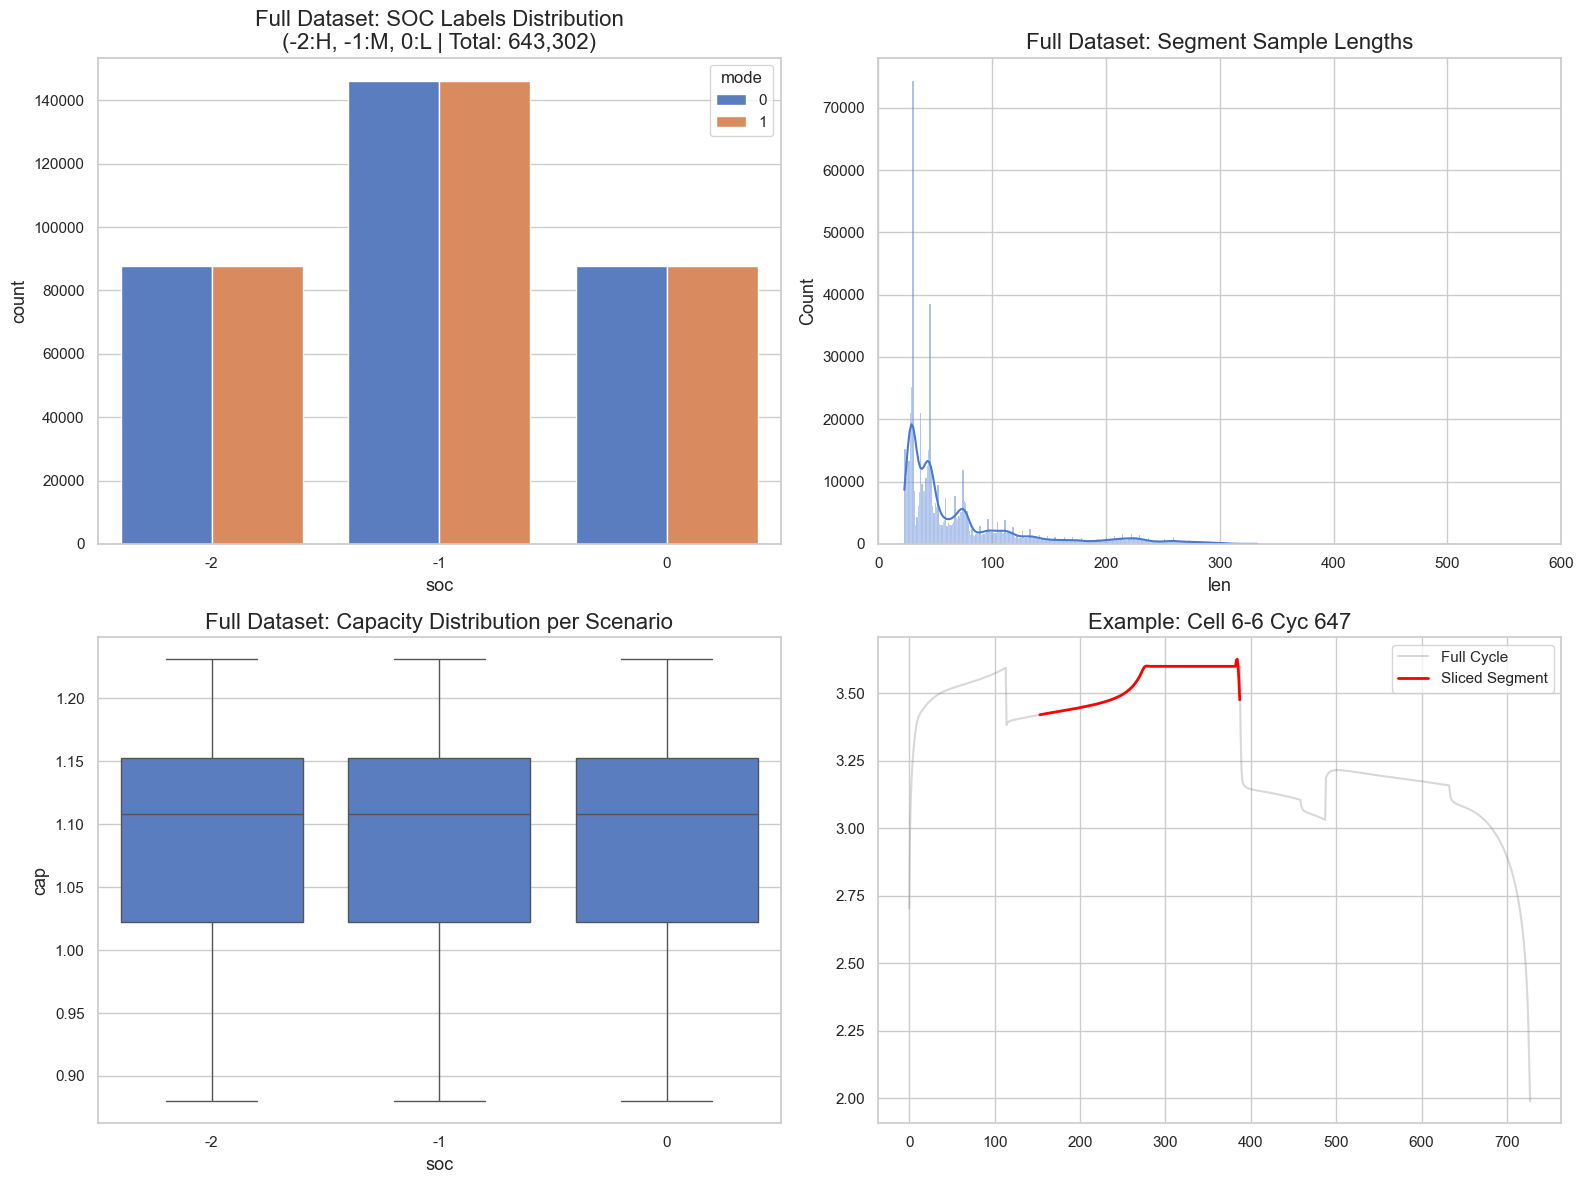

In [24]:
def plot_phase2_slicing_summary(segments, num_samples=3):
    # 1. 만약 segments가 비어있다면 디스크 캐시에서 '모든' 배치 파일 로드
    if not segments:
        print(f"[Info] 'segments'가 비어있습니다. {CACHE_DIR}에서 모든 배치를 로드합니다...")
        cache_files = sorted(CACHE_DIR.glob("batch_*.pkl"))
        if not cache_files:
            print(f"[Error] 캐시된 슬라이싱 배치 파일이 없습니다 ({CACHE_DIR}). Phase 2를 먼저 실행하세요.")
            return
        
        all_loaded_segments = []
        for cf in tqdm(cache_files, desc="Loading All Sliced Batches"):
            with open(cf, "rb") as f:
                batch_data = pickle.load(f)
                # 각 배치 파일 내부의 'segments' 리스트를 통합
                all_loaded_segments.extend(batch_data.get('segments', []))
        
        segments = all_loaded_segments
        print(f"총 {len(cache_files)}개의 배치 파일에서 {len(segments):,}개의 세그먼트를 모두 로드했습니다.")

    if not segments:
        print("[Error] 시각화할 데이터가 없습니다.")
        return

    # 2. 데이터프레임 변환 (전체 데이터 대상)
    # 샘플링 없이 range(len(segments))를 사용하여 전체 메타데이터 생성
    print(f"[Info] 전체 {len(segments):,}개 세그먼트에 대한 통계 분석 중...")
    
    df_meta = pd.DataFrame([{
        "soc": s["soc_label"],
        "mode": s["mode_label"],
        "len": len(s["df"]),
        "cap": s["capacity"]
    } for s in segments])

    # 3. 시각화 로직 (전체 분포 반영)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # SOC 라벨 및 충/방전 분포 (전체)
    sns.countplot(data=df_meta, x='soc', hue='mode', ax=axes[0,0])
    axes[0,0].set_title(
        f"Full Dataset: SOC Labels Distribution\n"
        f"(-2:H, -1:M, 0:L | Total: {len(df_meta):,})"
    )
    
    # 세그먼트 길이 분포 (전체)
    sns.histplot(data=df_meta, x='len', ax=axes[0,1], kde=True)
    axes[0,1].set_title("Full Dataset: Segment Sample Lengths")
    axes[0,1].set_xlim(0, 600)
    
    # 용량 분포 (전체)
    df_meta_nonzero = df_meta[df_meta['cap'] > 0]
    if not df_meta_nonzero.empty:
        sns.boxplot(data=df_meta_nonzero, x='soc', y='cap', ax=axes[1,0])
        axes[1,0].set_title("Full Dataset: Capacity Distribution per Scenario")
    
    # 샘플 시각화 (랜덤 하나)
    sample_s = random.choice(segments)
    cid, cyc = sample_s['cell'], sample_s['cyc']
    
    try:
        if 'all_cells' in globals() and cid in all_cells:
            full_df = all_cells[cid].data[cyc]
            
            axes[1,1].plot(
                full_df[COL_V].values,
                color='gray',
                alpha=0.3,
                label='Full Cycle'
            )
            
            axes[1,1].plot(
                sample_s['df'].index % len(full_df),
                sample_s['df'][COL_V].values,
                color='red',
                linewidth=2,
                label='Sliced Segment'
            )
            
            axes[1,1].set_title(f"Example: Cell {cid} Cyc {cyc}")
            axes[1,1].legend()
            
    except Exception as e:
        axes[1,1].text(
            0.5,
            0.5,
            f"Original data plot skipped\n({e})",
            ha='center'
        )
    
    plt.tight_layout()
    plt.savefig(FIGURE_ROOT / f"{DATASET_TYPE}_phase2_full_slicing_summary.png")
    plt.show()

plot_phase2_slicing_summary(all_raw_segments)

## Phase 3: 45D Adaptive HI Extraction Logic

In [7]:
from scipy.stats import skew, kurtosis, pearsonr
def extract_45d_hi(df, mode="C"):
    v_col = COL_V
    i_col = COL_I
    t_col = COL_TIME
    temp_col = COL_T
    
    v = df[v_col].values if v_col in df.columns else df.iloc[:, 1].values
    i_raw = df[i_col].values if i_col in df.columns else df.iloc[:, 2].values
    t = df[t_col].values if t_col in df.columns else df.iloc[:, 0].values
    temp = df[temp_col].values if temp_col in df.columns else np.full_like(v, 25.0)
    
    i_abs = np.abs(i_raw)
    dt_full = np.diff(t, prepend=t[0])
    dt_diff = np.where(np.diff(t) > 0, np.diff(t), 1e-6)
    dq_instant = (i_abs[1:] * dt_diff) / 3600.0
    dq_cum = np.cumsum(np.insert(dq_instant, 0, 0))
    his = {}
    his["c1_1_mean_v"] = np.mean(v)
    his["c1_2_var_v"] = np.var(v)
    his["c1_3_skew_v"] = skew(v) if np.std(v) > 1e-6 else 0.0
    his["c1_4_kurt_v"] = kurtosis(v) if np.std(v) > 1e-6 else 0.0
    his["c1_5_mean_t"] = np.mean(temp)
    his["c1_6_delta_t"] = np.max(temp) - np.min(temp)
    his["c1_7_dtdt"] = np.mean(np.diff(temp) / dt_diff)
    his["c1_8_mean_i"] = np.mean(i_abs)
    his["c1_9_var_i"] = np.var(i_abs)

    p_v = np.histogram(v, bins=10, density=True)[0]
    his["c1_10_ent_v"] = -np.sum(p_v * np.log(p_v + 1e-6))
    p_t = np.histogram(temp, bins=10, density=True)[0]
    his["c1_11_ent_t"] = -np.sum(p_t * np.log(p_t + 1e-6))

    his["c1_12_corr_vi"] = pearsonr(v, i_abs)[0] if np.std(v) > 1e-6 and np.std(i_abs) > 1e-6 else 0.0
    his["c1_13_corr_vt"] = pearsonr(v, temp)[0] if np.std(v) > 1e-6 and np.std(temp) > 1e-6 else 0.0
    his["c1_14_de_dq"] = np.sum(v * i_abs * dt_full) / (np.sum(i_abs * dt_full) + 1e-6)
    his["c1_15_power_var"] = np.var(v * i_raw)

    for j in range(1, 16): his[f"c2_dis_{j}"] = his[f"c3_cha_{j}"] = 0.0
    dvdt = np.diff(v) / dt_diff
    d2vdt2 = np.diff(dvdt) / np.where(dt_diff[1:] > 0, dt_diff[1:], 1e-6) if len(dvdt) > 1 else np.array([0.0])

    if mode == "D":
        his["c2_dis_1"] = np.mean(dvdt); his["c2_dis_2"] = np.var(dvdt); his["c2_dis_3"] = np.mean(d2vdt2)
        his["c2_dis_4"] = np.sum((np.max(v) - v) * dt_full)
        di = np.diff(i_raw); valid_di = np.abs(di) > 0.005
        his["c2_dis_5"] = np.mean(np.abs(np.diff(v)[valid_di] / di[valid_di])) if np.any(valid_di) else 0.0
        his["c2_dis_6"] = np.sum(v * i_abs * dt_full) / 3600.0
        his["c2_dis_7"] = np.sum(i_abs * dt_full) / 3600.0
        dvdq = np.diff(v) / np.where(dq_instant > 0, dq_instant, 1e-6)
        his["c2_dis_8"] = np.mean(dvdq); his["c2_dis_9"] = np.var(dvdq)
        his["c2_dis_10"] = np.min(v) / (np.max(v) + 1e-6)
        his["c2_dis_11"] = (temp[-1] - temp[0]) / (his["c2_dis_7"] + 1e-6)
        his["c2_dis_12"] = np.sum(np.abs(np.diff(dvdt)))
        his["c2_dis_13"] = np.sum(v * dt_full) / (np.mean(i_abs) + 1e-6)
        if len(dq_cum) > 1: his["c2_dis_14"] = np.polyfit(dq_cum, v, 1)[0]
        his["c2_dis_15"] = np.sum(v * dq_cum) / (np.sum(dq_cum) + 1e-6)
        
    elif mode == "C":
        his["c3_cha_1"] = np.mean(dvdt); his["c3_cha_2"] = np.var(dvdt); his["c3_cha_3"] = np.mean(d2vdt2)
        his["c3_cha_4"] = np.sum((v - np.min(v)) * dt_full)
        dv_pos = np.where(np.diff(v) > 0.0005, np.diff(v), 1e-6); dqdv = dq_instant / dv_pos
        his["c3_cha_5"] = np.mean(dqdv); his["c3_cha_6"] = np.var(dqdv)
        his["c3_cha_7"] = np.sum(v * i_abs * dt_full) / 3600.0
        his["c3_cha_8"] = np.sum(i_abs * dt_full) / 3600.0
        his["c3_cha_9"] = np.max(v) / (np.min(v) + 1e-6)
        his["c3_cha_10"] = (temp[-1] - temp[0]) / (his["c3_cha_8"] + 1e-6)
        his["c3_cha_11"] = np.sum(np.abs(np.diff(dvdt)))
        his["c3_cha_12"] = np.mean(i_abs) / (np.abs(np.mean(dvdt)) + 1e-6)
        p_dvdt = np.histogram(dvdt, bins=10, density=True)[0]
        his["c3_cha_13"] = -np.sum(p_dvdt * np.log(p_dvdt + 1e-6))
        his["c3_cha_14"] = np.max(dqdv) if len(dqdv) > 0 else 0.0
        his["c3_cha_15"] = np.sum((v[1:] - v[0]) * dq_instant)
    return pd.Series(his)

## Phase 3.1: Feature Extraction & Scaling

In [8]:
final_batch_files = sorted(FEATURE_BATCH_DIR.glob("final_*.pkl"))

if START_PHASE <= 3 or not final_batch_files:
    SKIP_EXTRACTION = False
    print(f"[Phase 3] Cache not found or START_PHASE <= 3. Starting Feature Extraction for {DATASET_TYPE}...")
else:
    SKIP_EXTRACTION = True
    print(f"[Phase 3] Cache found ({len(final_batch_files)} batches). Loading from {FEATURE_BATCH_DIR}...")
    batch_feature_pool = []
    for bf in tqdm(final_batch_files, desc="Loading cached features"): 
        with open(bf, "rb") as f: batch_feature_pool.extend(pickle.load(f))


[Phase 3] Cache found (10 batches). Loading from D:\chanminLee\data_store\LFP_SOH_estimation\hust_feature_batches...


Loading cached features:   0%|          | 0/10 [00:00<?, ?it/s]

In [9]:
if not SKIP_EXTRACTION:
    batch_files = sorted(CACHE_DIR.glob("batch_*.pkl"))
    scaler = StandardScaler()
    total_items_extracted = 0

    # --- [Step 1: Extraction & Fit Scaler] ---
    for batch_file in tqdm(batch_files, desc="Extraction & Fitting"):
        batch_id = batch_file.stem
        with open(batch_file, "rb") as f: batch_data = pickle.load(f)
        batch_raw_pool = []
        for item in tqdm(batch_data['segments'], desc=f"  [{batch_id}]", leave=False):
            # Extract 45D HI
            hi = extract_45d_hi(item['df'], "C" if item['mode_label'] == 1 else "D")
            batch_raw_pool.append({
                "cell": item['cell'], "cyc": item['cyc'], 
                "x": hi, # Use 'x' for raw features per convention
                "soc_label": item['soc_label'], "mode_label": item['mode_label'],
                "length_p": item['length_p'], "y": item.get('rul', item.get('y', 0.0)),
                "capacity": item.get('capacity', 0.0)
            })
        # Partial fit for memory efficiency
        raw_x_batch = [item['x'] for item in batch_raw_pool]
        scaler.partial_fit(raw_x_batch)
        
        # Save intermediate raw features
        with open(FEATURE_BATCH_DIR / f"raw_{batch_id}.pkl", "wb") as f: pickle.dump(batch_raw_pool, f)
        total_items_extracted += len(batch_raw_pool)
        del batch_data, batch_raw_pool; gc.collect()

    # --- [Step 2: Scaling & Masking] ---
    batch_feature_pool = []
    raw_batch_files = sorted(FEATURE_BATCH_DIR.glob("raw_batch_*.pkl"))
    for raw_file in tqdm(raw_batch_files, desc="Scaling & Saving"):
        batch_id = raw_file.stem.replace("raw_", "")
        with open(raw_file, "rb") as f: batch_pool = pickle.load(f)
        
        raw_x_vals = [item['x'] for item in batch_pool]
        scaled_x_vals = scaler.transform(raw_x_vals)
        
        for i, item in enumerate(batch_pool):
            s_x = scaled_x_vals[i]
            # Scenario-aware Masking (f0-14: Common, f15-29: Discharge, f30-44: Charge)
            if item['mode_label'] == 1: s_x[15:30] = 0.0 # Charge mode: mask discharge features
            else: s_x[30:45] = 0.0 # Discharge mode: mask charge features
            
            # Inject Metadata (SOC, Mode, Length)
            meta = np.array([item['soc_label'], item['mode_label'], item['length_p']], dtype=np.float32)
            item['scaled_x'] = np.concatenate([s_x, meta]) # Use 'scaled_x' for scaled features
            
        # Save final batch
        with open(FEATURE_BATCH_DIR / f"final_{batch_id}.pkl", "wb") as f: pickle.dump(batch_pool, f)
        batch_feature_pool.extend(batch_pool)
        raw_file.unlink() # Cleanup raw cache
        
    with open(SCALER_CACHE_PATH, "wb") as f: pickle.dump(scaler, f)
    print(f"[Success] Extraction and Scaling complete. Total items: {len(batch_feature_pool):,}")


## Phase 3.2: Feature & Label Analysis

[Analysis] Using feature key: 'scaled_x'


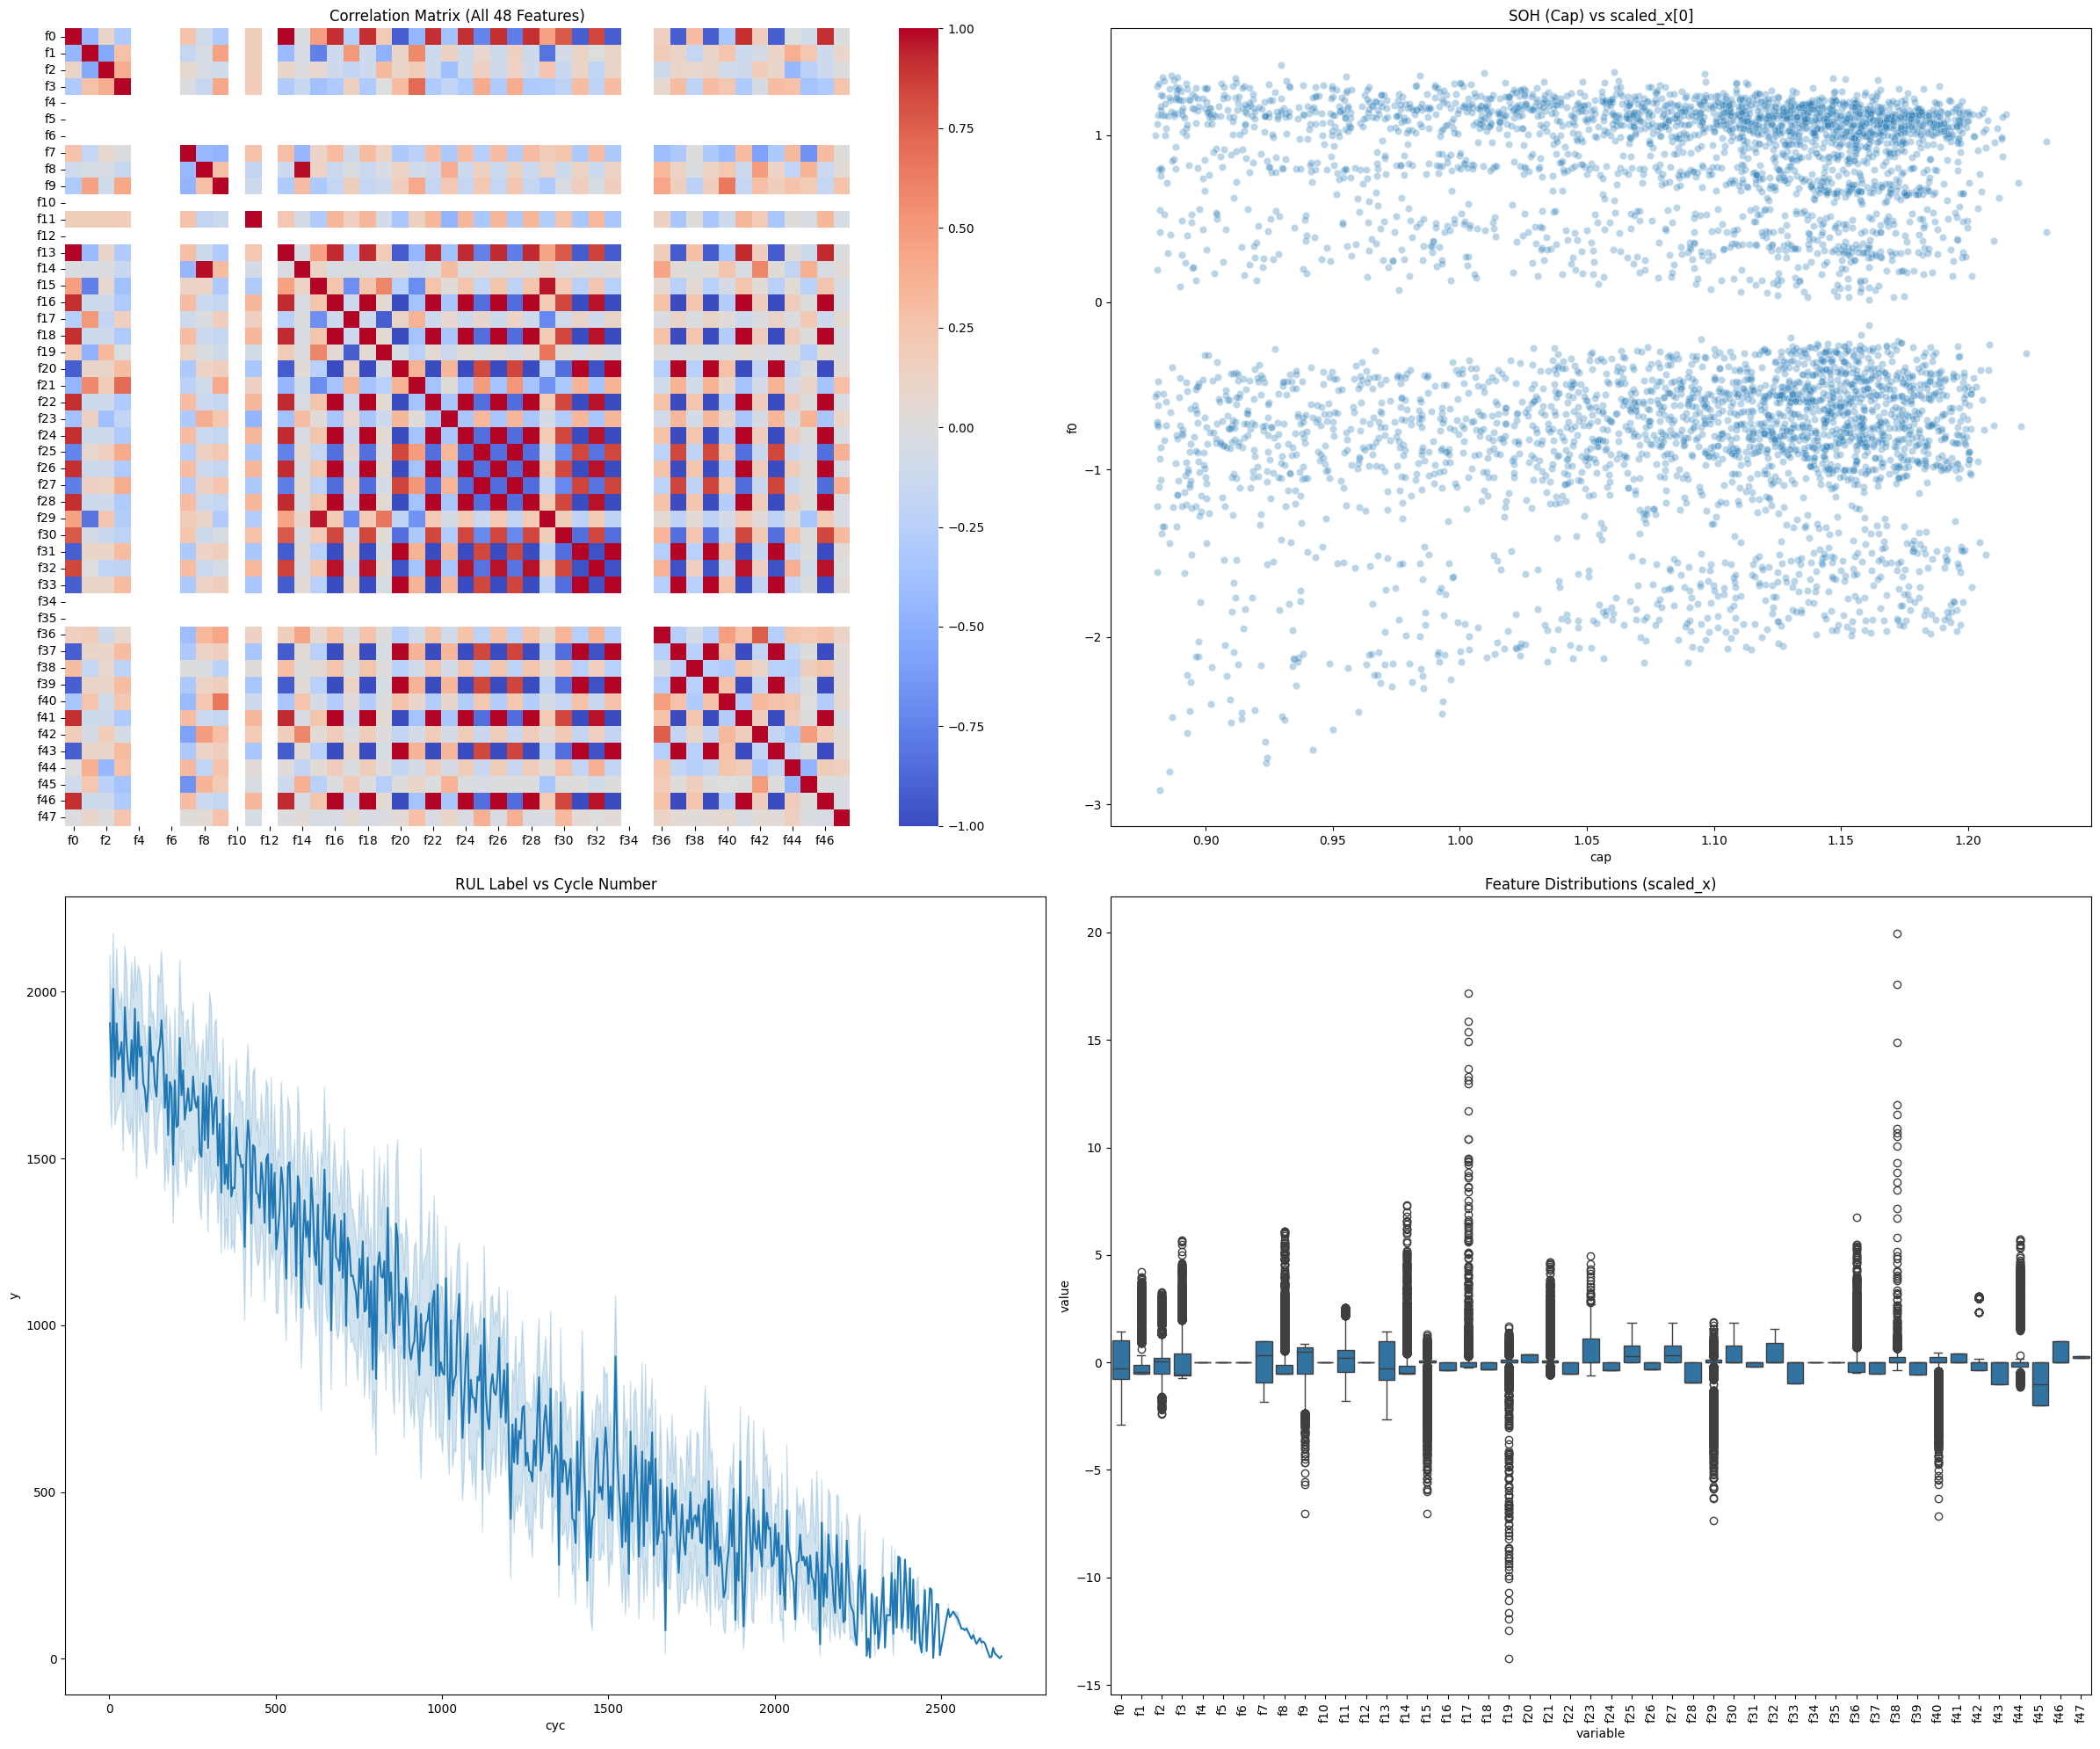

In [10]:
def plot_phase4_feature_analysis(pool):
    import random
    if not pool: return
    
    # Decide which feature to use
    sample_item = pool[0]
    feature_key = 'scaled_x' if 'scaled_x' in sample_item else 'x'
    print(f"[Analysis] Using feature key: '{feature_key}'")
    
    num_features = len(sample_item[feature_key])
    sample_pool = random.sample(pool, min(5000, len(pool)))
    df_features = pd.DataFrame([{
        "cyc": s["cyc"], "y": s.get("y", s.get("rul", 0)), "cap": s["capacity"],
        **{f"f{i}": val for i, val in enumerate(s[feature_key])}
    } for s in sample_pool])
    
    fig, axes = plt.subplots(2, 2, figsize=(24, 20))
    corr = df_features[[f"f{i}" for i in range(num_features)]].corr()
    sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[0,0])
    axes[0,0].set_title(f"Correlation Matrix (All {num_features} Features)")
    sns.scatterplot(data=df_features, x='cap', y='f0', alpha=0.3, ax=axes[0,1])
    axes[0,1].set_title(f"SOH (Cap) vs {feature_key}[0]")
    sns.lineplot(data=df_features, x='cyc', y='y', ax=axes[1,0])
    axes[1,0].set_title("RUL Label vs Cycle Number")
    sns.boxplot(data=df_features.melt(value_vars=[f"f{i}" for i in range(num_features)]), x='variable', y='value', ax=axes[1,1])
    axes[1,1].set_title(f"Feature Distributions ({feature_key})")
    axes[1,1].tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.savefig(FIGURE_ROOT / f"{DATASET_TYPE}_feature_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

if 'batch_feature_pool' in globals() and len(batch_feature_pool) > 0:
    plot_phase4_feature_analysis(batch_feature_pool)
else:
    print("No data found in memory for analysis.")


## Phase 4: Final Saving

In [11]:
if START_PHASE <= 4 or not FINAL_TENSOR_PATH.exists():
    print(f"[Phase 4] Starting Final Tensor Saving for {DATASET_TYPE}...")
    if 'batch_feature_pool' not in globals() or not batch_feature_pool:
        print("[Error] No feature batches found in memory. Please run Phase 3 first.")
    else:
        final_data = []
        for item in tqdm(batch_feature_pool, desc="Formatting Optimized Tensors"):
            # Use 'scaled_x' if available, otherwise 'x'
            x_val = item.get('scaled_x', item.get('x'))
            
            final_data.append({
                "cell": item['cell'], "cyc": item['cyc'], "x": x_val,
                "soc_label": item['soc_label'], "mode_label": item['mode_label'],
                "length_p": item['length_p'], 
                "y": item.get('y', item.get('rul', 0.0)),
                "capacity": item.get('capacity', 0.0)
            })
        with open(FINAL_TENSOR_PATH, "wb") as f: 
            pickle.dump(final_data, f)
        print(f"[Success] Mapped and saved {len(final_data):,} samples to {FINAL_TENSOR_PATH}")
else:
    print(f"[Phase 4] Skipping Final Tensor Saving. Optimized file already exists.")


[Phase 4] Starting Final Tensor Saving for hust...


Formatting Optimized Tensors:   0%|          | 0/643302 [00:00<?, ?it/s]

[Success] Mapped and saved 643,302 samples to D:\chanminLee\data_store\LFP_SOH_estimation\hust_optimized_tensors.pkl


## Phase 5: Visualization

Loading 10 batches for visualization...


Loading batches:   0%|          | 0/10 [00:00<?, ?it/s]

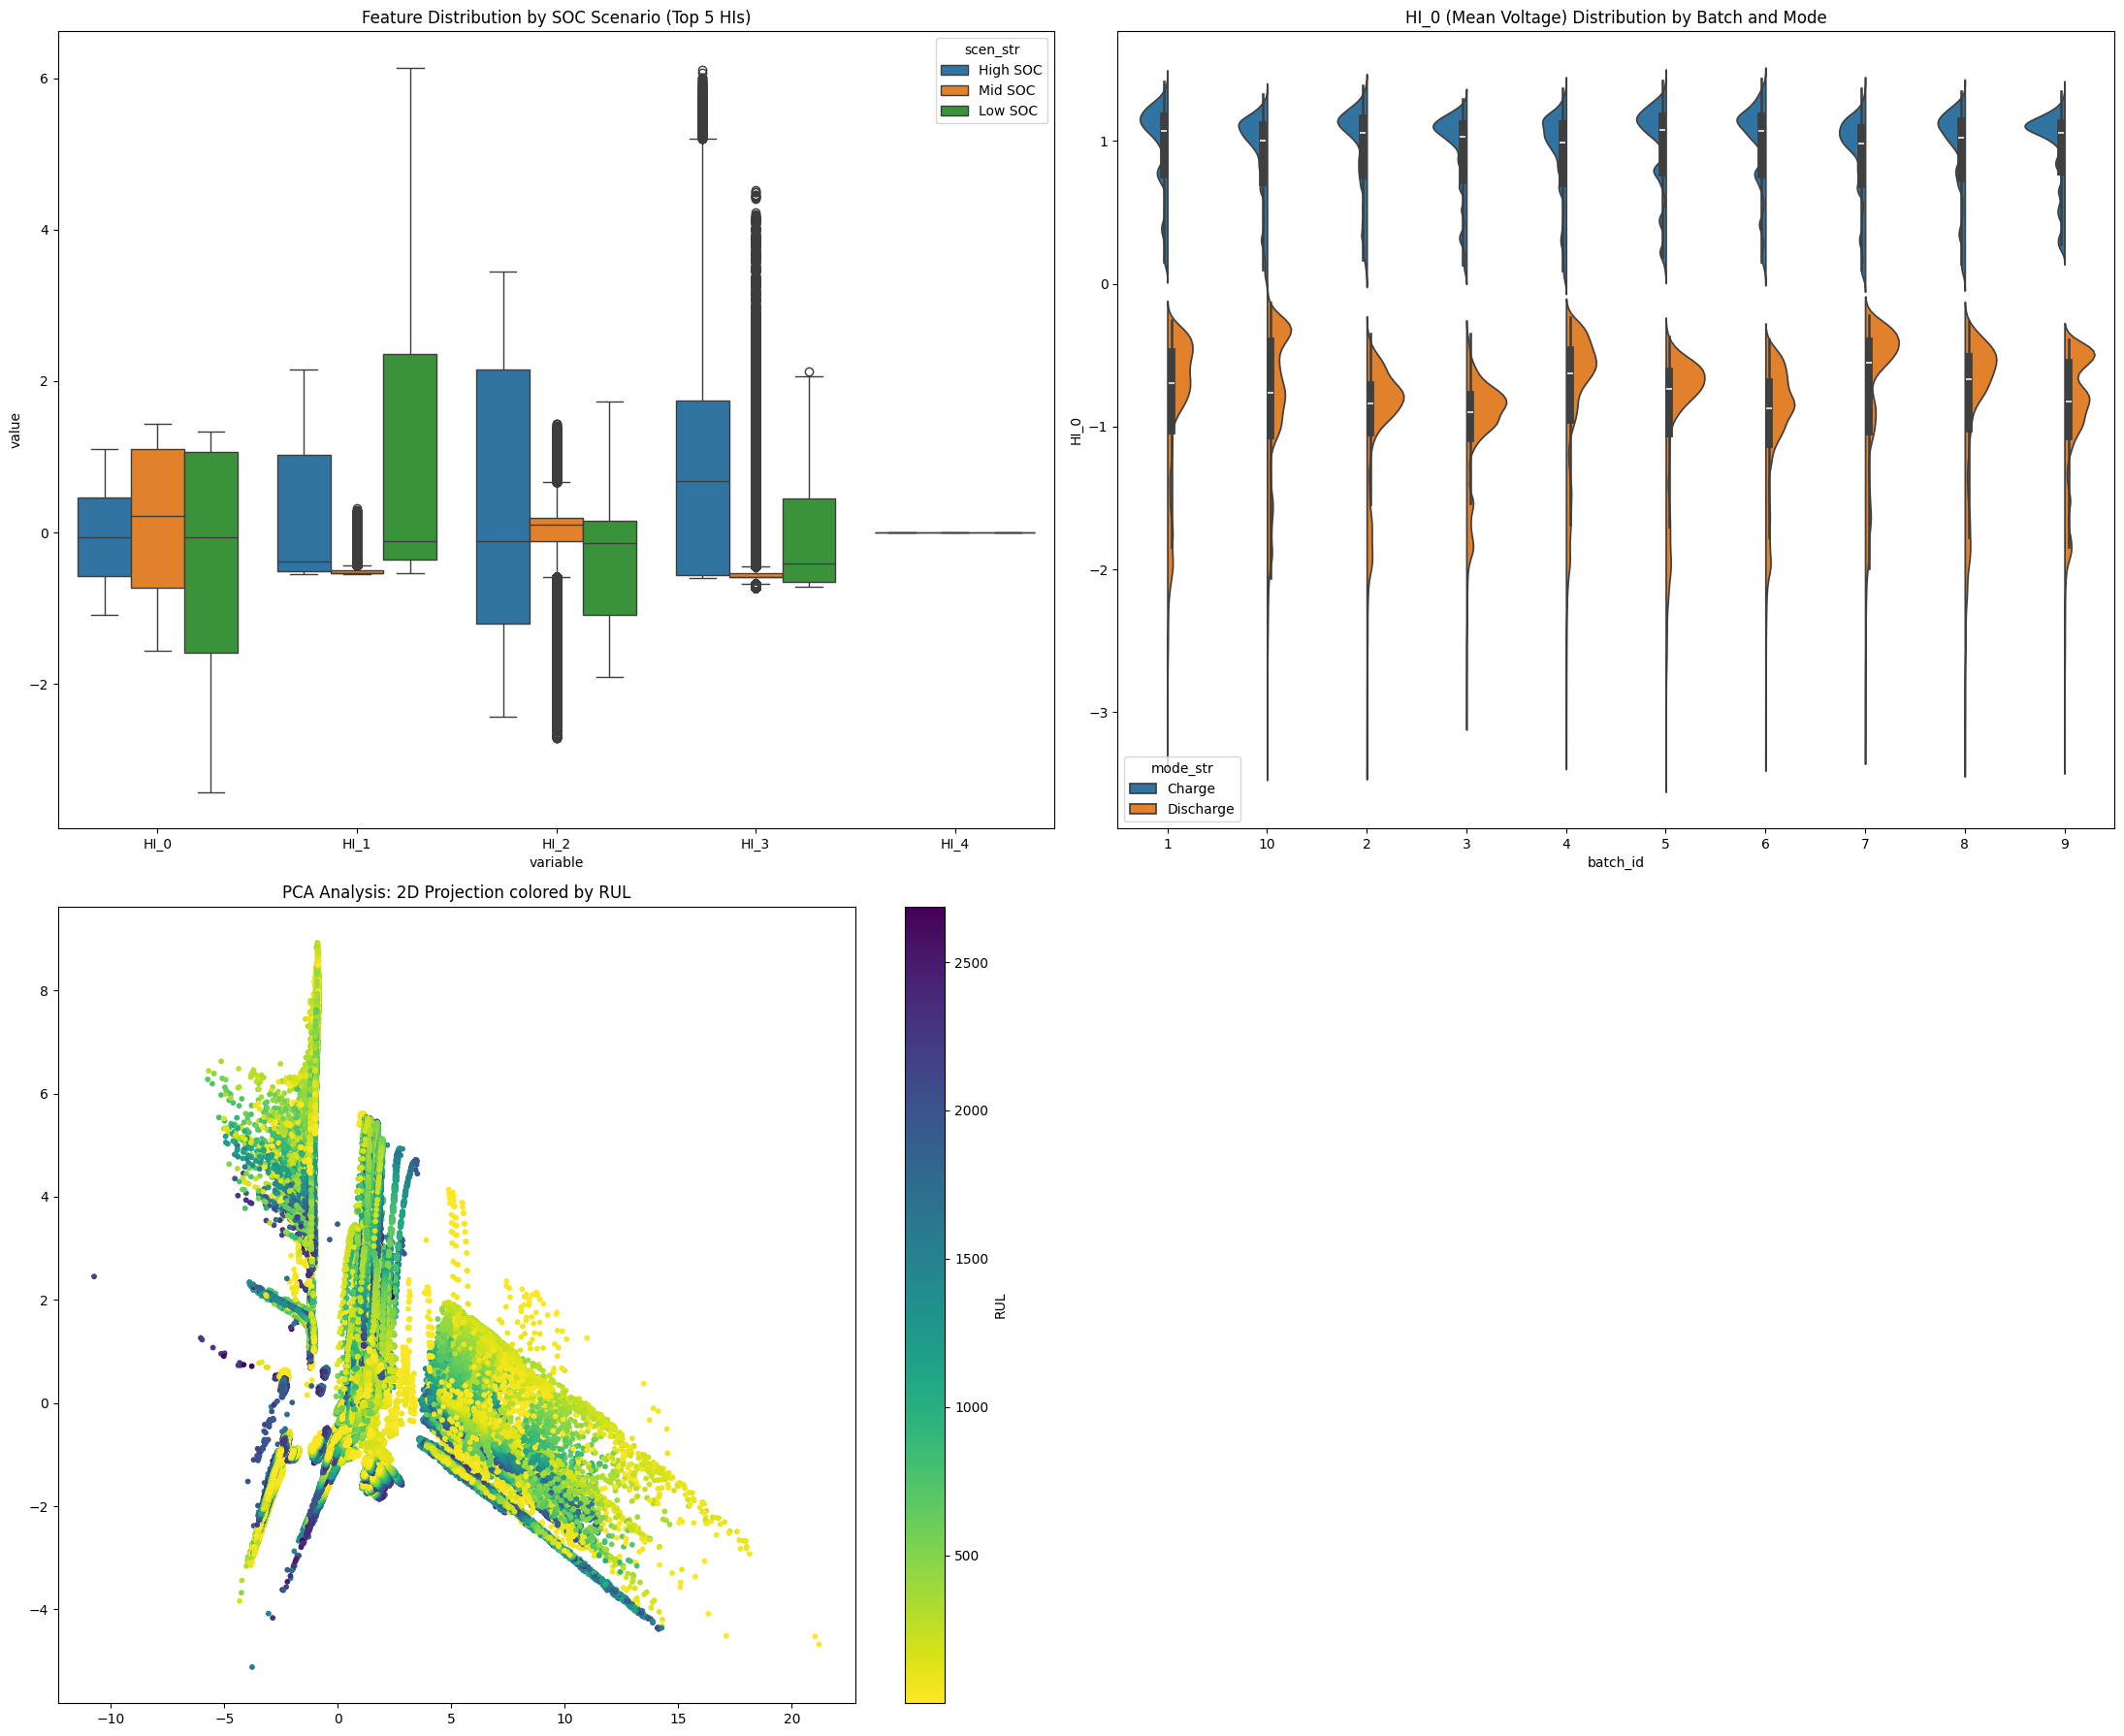

In [12]:
from sklearn.decomposition import PCA
def analyze_final_hi_dataset(dataset_type):
    FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{dataset_type}_feature_batches"
    final_batch_files = sorted(FEATURE_BATCH_DIR.glob("final_batch_*.pkl"))
    
    if not final_batch_files:
        print(f"Error: No batch files found in {FEATURE_BATCH_DIR}")
        return

    all_data = []
    print(f"Loading {len(final_batch_files)} batches for visualization...")
    for bf in tqdm(final_batch_files, desc="Loading batches"): 
        with open(bf, "rb") as f: 
            batch_data = pickle.load(f)
            # Ensure consistent key naming ('scaled_x' -> 'x')
            for item in batch_data:
                if 'scaled_x' in item and 'x' not in item:
                    item['x'] = item['scaled_x']
                if 'rul' in item and 'y' not in item:
                    item['y'] = item['rul']
            all_data.extend(batch_data)
    
    if not all_data:
        print("Error: Loaded data pool is empty.")
        return

    df = pd.DataFrame(all_data)
    x_expanded = pd.DataFrame(df['x'].tolist())
    x_expanded.columns = [f"HI_{i}" for i in range(x_expanded.shape[1])]
    df = pd.concat([df.drop('x', axis=1), x_expanded], axis=1)
    
    df['batch_id'] = df['cell'].apply(lambda cid: get_batch_id(cid, dataset_type))
    df['scen_str'] = df['soc_label'].map({-2: 'High SOC', -1: 'Mid SOC', 0: 'Low SOC'})
    df['mode_str'] = df['mode_label'].map({1: 'Charge', 0: 'Discharge'})
    
    fig = plt.figure(figsize=(22, 18))
    ax1 = plt.subplot(2, 2, 1)
    # Only plot first 5 features for clarity
    sns.boxplot(data=df.melt(id_vars=['scen_str'], value_vars=[f"HI_{i}" for i in range(5)]), x='variable', y='value', hue='scen_str', ax=ax1)
    ax1.set_title("Feature Distribution by SOC Scenario (Top 5 HIs)")
    
    ax2 = plt.subplot(2, 2, 2)
    sns.violinplot(data=df, x='batch_id', y='HI_0', hue='mode_str', split=True, ax=ax2)
    ax2.set_title("HI_0 (Mean Voltage) Distribution by Batch and Mode")
    
    ax3 = plt.subplot(2, 2, 3)
    pca = PCA(n_components=2); hi_cols = [f"HI_{i}" for i in range(x_expanded.shape[1])]
    pca_res = pca.fit_transform(df[hi_cols].dropna())
    sc = plt.scatter(pca_res[:, 0], pca_res[:, 1], c=df.dropna(subset=hi_cols)['y'], cmap='viridis_r', s=10)
    plt.colorbar(sc, label='RUL')
    ax3.set_title("PCA Analysis: 2D Projection colored by RUL")
    
    plt.tight_layout()
    plt.savefig(figure_path / f"{dataset_type}_hi_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_hi_comprehensive_analysis(df):
    """Creates a comprehensive dashboard of HI characteristics."""
    import matplotlib.gridspec as gridspec
    hi_cols = [f"HI_{i}" for i in range(10)] # Top 10 HIs
    
    fig = plt.figure(figsize=(24, 16))
    gs = gridspec.GridSpec(3, 3, figure=fig)
    
    # 1. HI Trend over Cycles (Top 3 HIs)
    ax1 = fig.add_subplot(gs[0, :2])
    for i in range(3):
        sns.lineplot(data=df, x='cyc', y=f'HI_{i}', label=f'HI_{i}', ax=ax1, alpha=0.7)
    ax1.set_title("Degradation Trends: Top 3 HIs over Cycle Number")
    ax1.set_xlabel("Cycle Number")
    ax1.set_ylabel("Scaled Value")
    
    # 2. HI vs Capacity Correlation Heatmap
    ax2 = fig.add_subplot(gs[0, 2])
    corr_target = df[hi_cols + ['capacity']].corr()[['capacity']].sort_values(by='capacity', ascending=False)
    sns.heatmap(corr_target, annot=True, cmap='RdBu_r', ax=ax2)
    ax2.set_title("HI Correlation with Capacity (SOH)")
    
    # 3. HI Distribution across SOC Scenarios (HI_0)
    ax3 = fig.add_subplot(gs[1, 0])
    sns.boxplot(data=df, x='scen_str', y='HI_0', hue='mode_str', ax=ax3)
    ax3.set_title("HI_0 Distribution by SOC & Mode")
    
    # 4. Feature Space Clustering (PCA)
    ax4 = fig.add_subplot(gs[1, 1:])
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(df[hi_cols].dropna())
    scatter = ax4.scatter(pca_res[:, 0], pca_res[:, 1], c=df.dropna(subset=hi_cols)['capacity'], 
                         cmap='magma', s=5, alpha=0.5)
    plt.colorbar(scatter, ax=ax4, label='Capacity (Ah)')
    ax4.set_title("PCA Projection: HI Feature Space colored by SOH")
    
    # 5. Density of SOH Labels
    ax5 = fig.add_subplot(gs[2, 0])
    sns.kdeplot(data=df, x='capacity', hue='scen_str', fill=True, ax=ax5)
    ax5.set_title("Capacity Density by Scenario")
    
    # 6. HI_1 vs HI_2 scatter colored by RUL
    ax6 = fig.add_subplot(gs[2, 1:])
    scatter2 = ax6.scatter(df['HI_1'], df['HI_2'], c=df['y'], cmap='viridis_r', s=5, alpha=0.4)
    plt.colorbar(scatter2, ax=ax6, label='RUL')
    ax6.set_title("HI Interaction: HI_1 vs HI_2 colored by RUL")
    
    plt.tight_layout()
    fig.savefig(figure_path / f"{DATASET_TYPE}_hi_comprehensive_analysis.png", dpi=300)
    plt.show()

# Execute Comprehensive Analysis
if 'all_data' in locals() and len(all_data) > 0:
    # Re-use the already loaded and processed DataFrame if available
    df_final = pd.DataFrame(all_data)
    x_expanded = pd.DataFrame(df_final['x'].tolist())
    x_expanded.columns = [f"HI_{i}" for i in range(x_expanded.shape[1])]
    df_final = pd.concat([df_final.drop('x', axis=1), x_expanded], axis=1)
    df_final['scen_str'] = df_final['soc_label'].map({-2: 'High SOC', -1: 'Mid SOC', 0: 'Low SOC'})
    df_final['mode_str'] = df_final['mode_label'].map({1: 'Charge', 0: 'Discharge'})
    
    plot_hi_comprehensive_analysis(df_final)

analyze_final_hi_dataset(DATASET_TYPE)

DataFrame for Analysis: 10000 samples, 52 columns (including features)
Feature columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47']


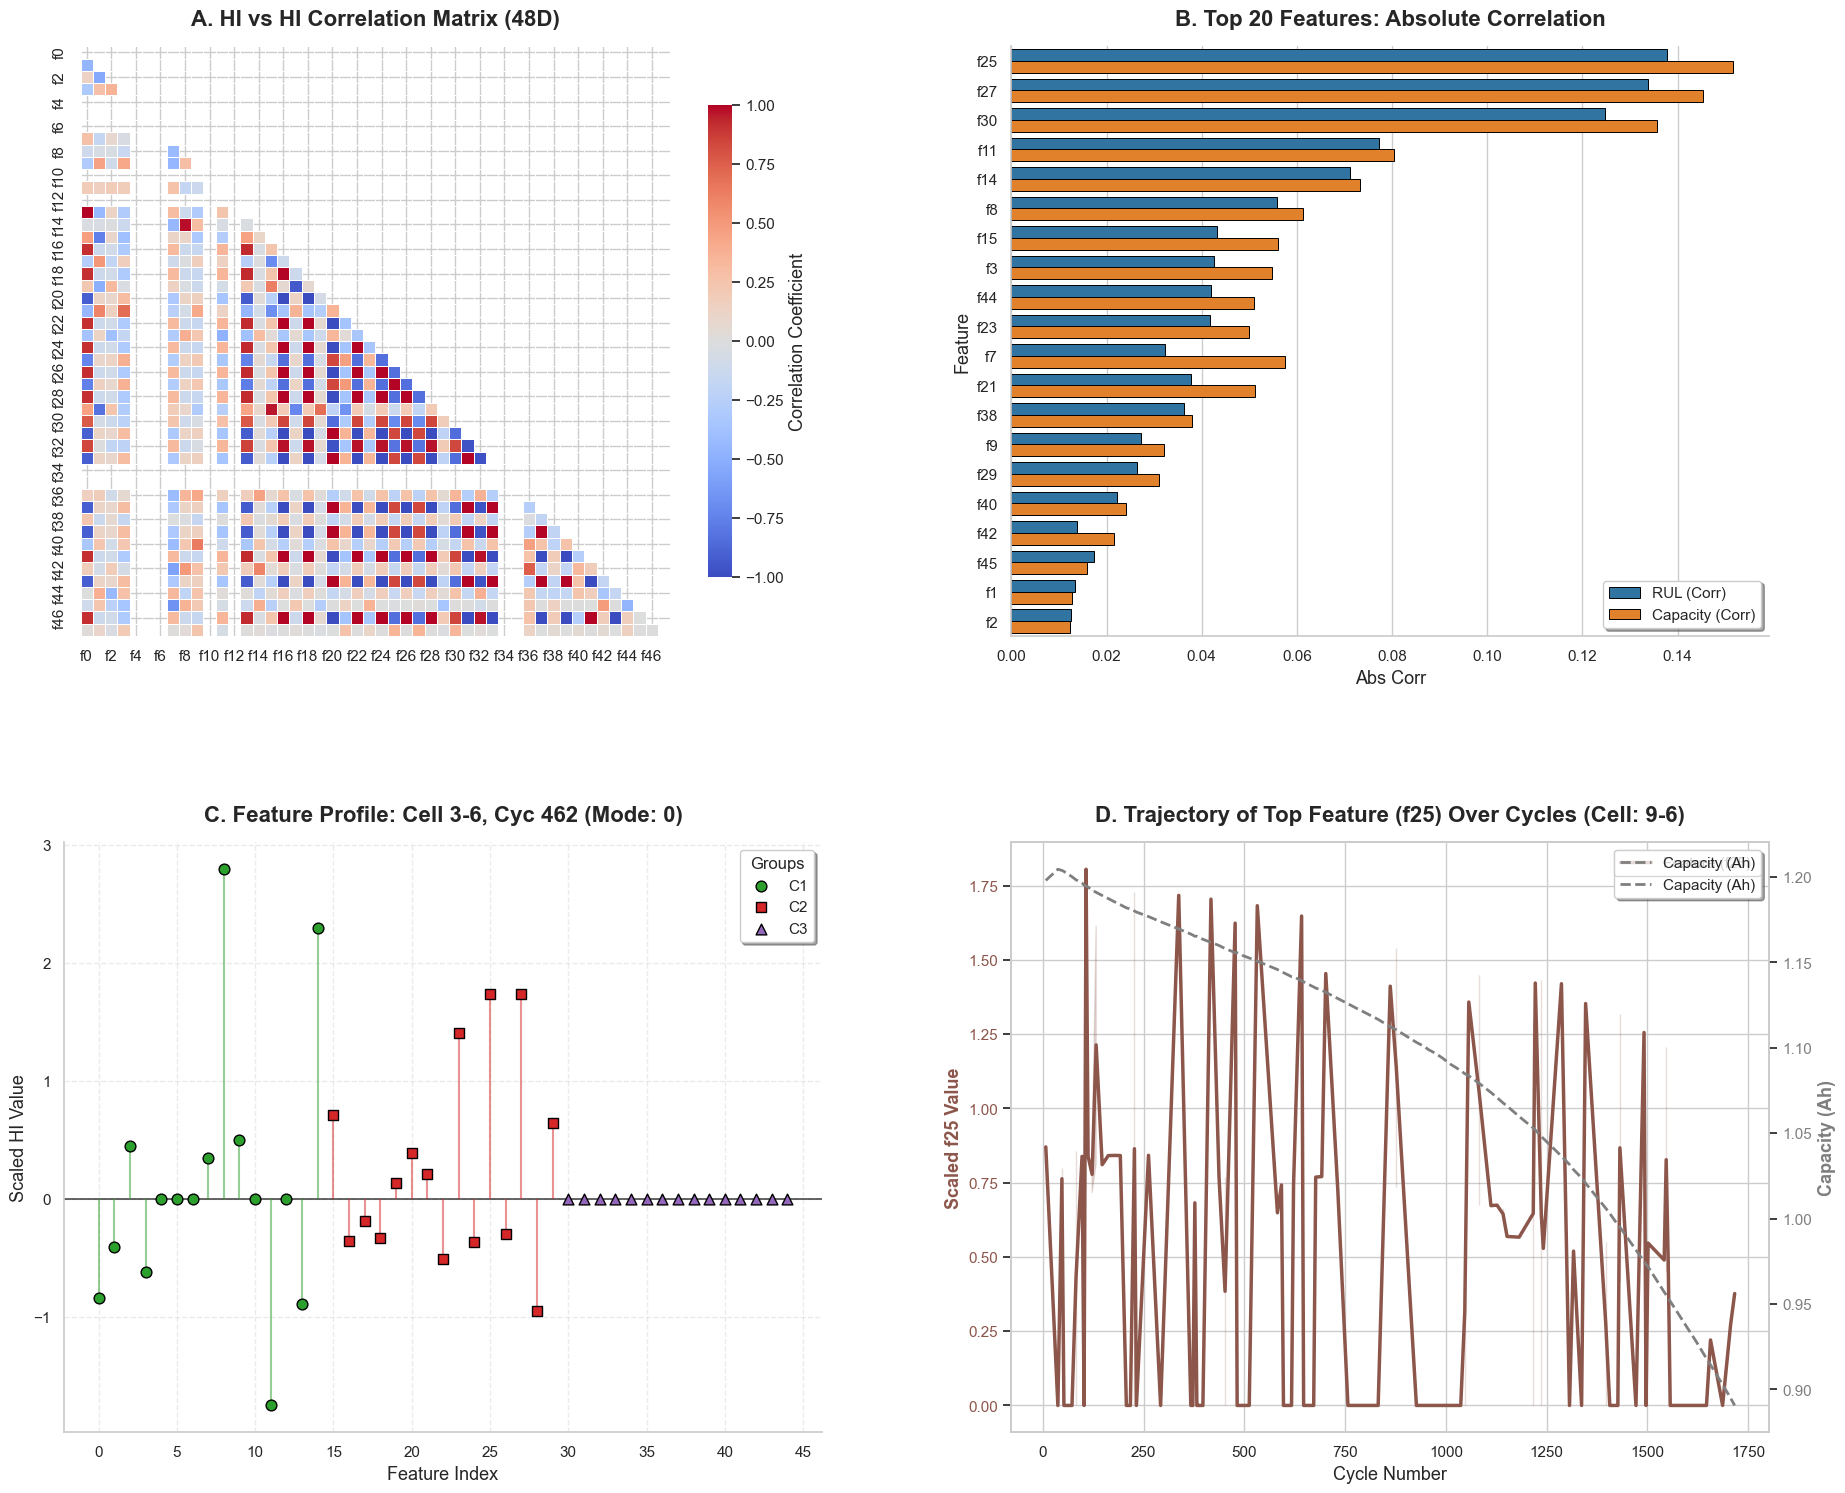

Comprehensive HI Analysis saved to: ..\..\outputs\figures\0513/hust_comprehensive_HI_analysis.png


In [13]:
def plot_comprehensive_hi_analysis(pool, save_path=f"{figure_path}/{DATASET_TYPE}_comprehensive_HI_analysis.png"):
    if not pool:
        print("No data in pool for analysis.")
        return

    # --- [디자인 테마 및 폰트 전역 설정] ---
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 13,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white'
    })

    # 1. 데이터 프레임 준비
    num_features = len(pool[0]["scaled_x"])
    sample_size = min(10000, len(pool))
    sample_pool = random.sample(pool, sample_size)

    data_dict = []
    for s in sample_pool:
        row = {
            "cell": s["cell"],
            "cyc": s["cyc"],
            "y_rul": s["y"],
            "cap_soh": s["capacity"]
        }
        for i, val in enumerate(s["scaled_x"]):
            row[f"f{i}"] = val
        data_dict.append(row)

    df = pd.DataFrame(data_dict)
    feature_cols = [f"f{i}" for i in range(num_features)]

    fig, axes = plt.subplots(2, 2, figsize=(22, 18))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)


    print(f"DataFrame for Analysis: {df.shape[0]} samples, {df.shape[1]} columns (including features)")
    print(f"Feature columns: {feature_cols}")

    # --- [Plot 1: HI vs HI Correlation Matrix (45D)] ---
    corr_matrix = df[feature_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        ax=axes[0, 0],
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, 'label': 'Correlation Coefficient'}
    )
    axes[0, 0].set_title(f"A. HI vs HI Correlation Matrix ({num_features}D)", fontweight='bold', pad=15)

    # --- [Plot 2: Top 20 Feat. Correlation with Target Variables] ---
    corrs_rul = df[feature_cols].corrwith(df["y_rul"]).abs()
    corrs_cap = df[feature_cols].corrwith(df["cap_soh"]).abs()

    top_20_idx = (corrs_rul + corrs_cap).sort_values(ascending=False).head(20).index
    df_top_corr = pd.DataFrame({
        "Feature": top_20_idx,
        "RUL (Corr)": corrs_rul[top_20_idx],
        "Capacity (Corr)": corrs_cap[top_20_idx]
    }).melt(id_vars="Feature", var_name="Target", value_name="Abs Corr")

    sns.barplot(
        data=df_top_corr,
        x="Abs Corr",
        y="Feature",
        hue="Target",
        palette={"RUL (Corr)": "#1f77b4", "Capacity (Corr)": "#ff7f0e"},
        ax=axes[0, 1],
        edgecolor='black',
        linewidth=0.7
    )
    axes[0, 1].set_title("B. Top 20 Features: Absolute Correlation", fontweight='bold', pad=15)
    axes[0, 1].legend(loc='lower right', frameon=True, shadow=True)
    sns.despine(ax=axes[0, 1])

    # --- [Plot 3: Feature Profile for Single Segment (Stem Plot 스타일)] ---
    sample_seg = random.choice(pool)
    cid, cyc, mode = sample_seg['cell'], sample_seg['cyc'], sample_seg['mode_label']
    feat_values = np.array(sample_seg["scaled_x"])

    axes[1, 0].axhline(0, color='black', linewidth=1.2, alpha=0.7)

    groups = [
        (range(0, 15), feat_values[0:15], '#2ca02c', 'o', 'C1'),
        (range(15, 30), feat_values[15:30], '#d62728', 's', 'C2'),
        (range(30, 45), feat_values[30:45], '#9467bd', '^', 'C3')
    ]

    for idx_range, values, color, marker, label in groups:
        axes[1, 0].vlines(idx_range, ymin=0, ymax=values, color=color, alpha=0.5, linewidth=1.5)
        axes[1, 0].scatter(idx_range, values, color=color, marker=marker, s=60,
                           label=label, edgecolors='black', zorder=3)

    axes[1, 0].set_title(f"C. Feature Profile: Cell {cid}, Cyc {cyc} (Mode: {mode})", fontweight='bold', pad=15)
    axes[1, 0].set_xlabel("Feature Index")
    axes[1, 0].set_ylabel("Scaled HI Value")
    axes[1, 0].legend(frameon=True, shadow=True, title="Groups")
    axes[1, 0].grid(True, linestyle='--', alpha=0.4)
    axes[1, 0].set_xticks(range(0, 46, 5))
    sns.despine(ax=axes[1, 0])

    # --- [Plot 4: Trajectory of Top Feature over Cycles] ---
    best_feat = corrs_cap.idxmax()
    target_cell = df['cell'].iloc[0]
    df_cell = df[df['cell'] == target_cell].sort_values("cyc")

    color_feat, color_cap = '#8c564b', '#7f7f7f'
    sns.lineplot(data=df_cell, x="cyc", y=best_feat,
                 ax=axes[1, 1], color=color_feat, linewidth=2.5,
                 label=f"Feature ({best_feat})")

    axes[1, 1].set_title(
        f"D. Trajectory of Top Feature ({best_feat}) Over Cycles (Cell: {target_cell})",
        fontweight='bold',
        pad=15
    )
    axes[1, 1].set_xlabel("Cycle Number")
    axes[1, 1].set_ylabel(f"Scaled {best_feat} Value", color=color_feat, fontweight='bold')
    axes[1, 1].tick_params(axis='y', labelcolor=color_feat)

    ax2 = axes[1, 1].twinx()
    sns.lineplot(data=df_cell, x="cyc", y="cap_soh",
                 ax=ax2, color=color_cap, linewidth=2,
                 linestyle='--', label="Capacity (Ah)")

    ax2.set_ylabel("Capacity (Ah)", color=color_cap, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_cap)
    ax2.grid(False)

    lines_1, labels_1 = axes[1, 1].get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    axes[1, 1].legend(lines_1 + lines_2, labels_1 + labels_2,
                      loc='upper right', frameon=True, shadow=True)

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Comprehensive HI Analysis saved to: {save_path}")


# 시각화 실행
if 'batch_feature_pool' in locals() and len(batch_feature_pool) > 0:
    plot_comprehensive_hi_analysis(batch_feature_pool)


Filtered 175446 samples for soc_label 0 with scaled_x shape: (175446, 48)
=== [Deep Analysis] High SOC Scenario (soc_label: 0) ===
1. Total Segments: 175446
2. Unique Cells  : 77
3. Avg. Capacity : 1.0826 Ah
--------------------------------------------------


c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))



[Top 10 Health Indicators by Correlation with SOH]
     SOH_Correlation      mean       std
f8         -0.259641  0.494453  1.168971
f14        -0.241669  0.591752  1.338860
f23        -0.180919  0.517858  1.073115
f27         0.147247  0.467462  0.552771
f30         0.144460  0.491474  0.576175
f25         0.137611  0.427478  0.513554
f7         -0.133080 -1.174414  0.484815
f11        -0.129696  0.240492  1.215463
f21         0.104218  0.748339  1.081820
f29         0.083429 -0.941559  1.499878


C:\Users\ksshin\AppData\Local\Temp\ipykernel_64684\3394819623.py:59: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3, 1, 1)


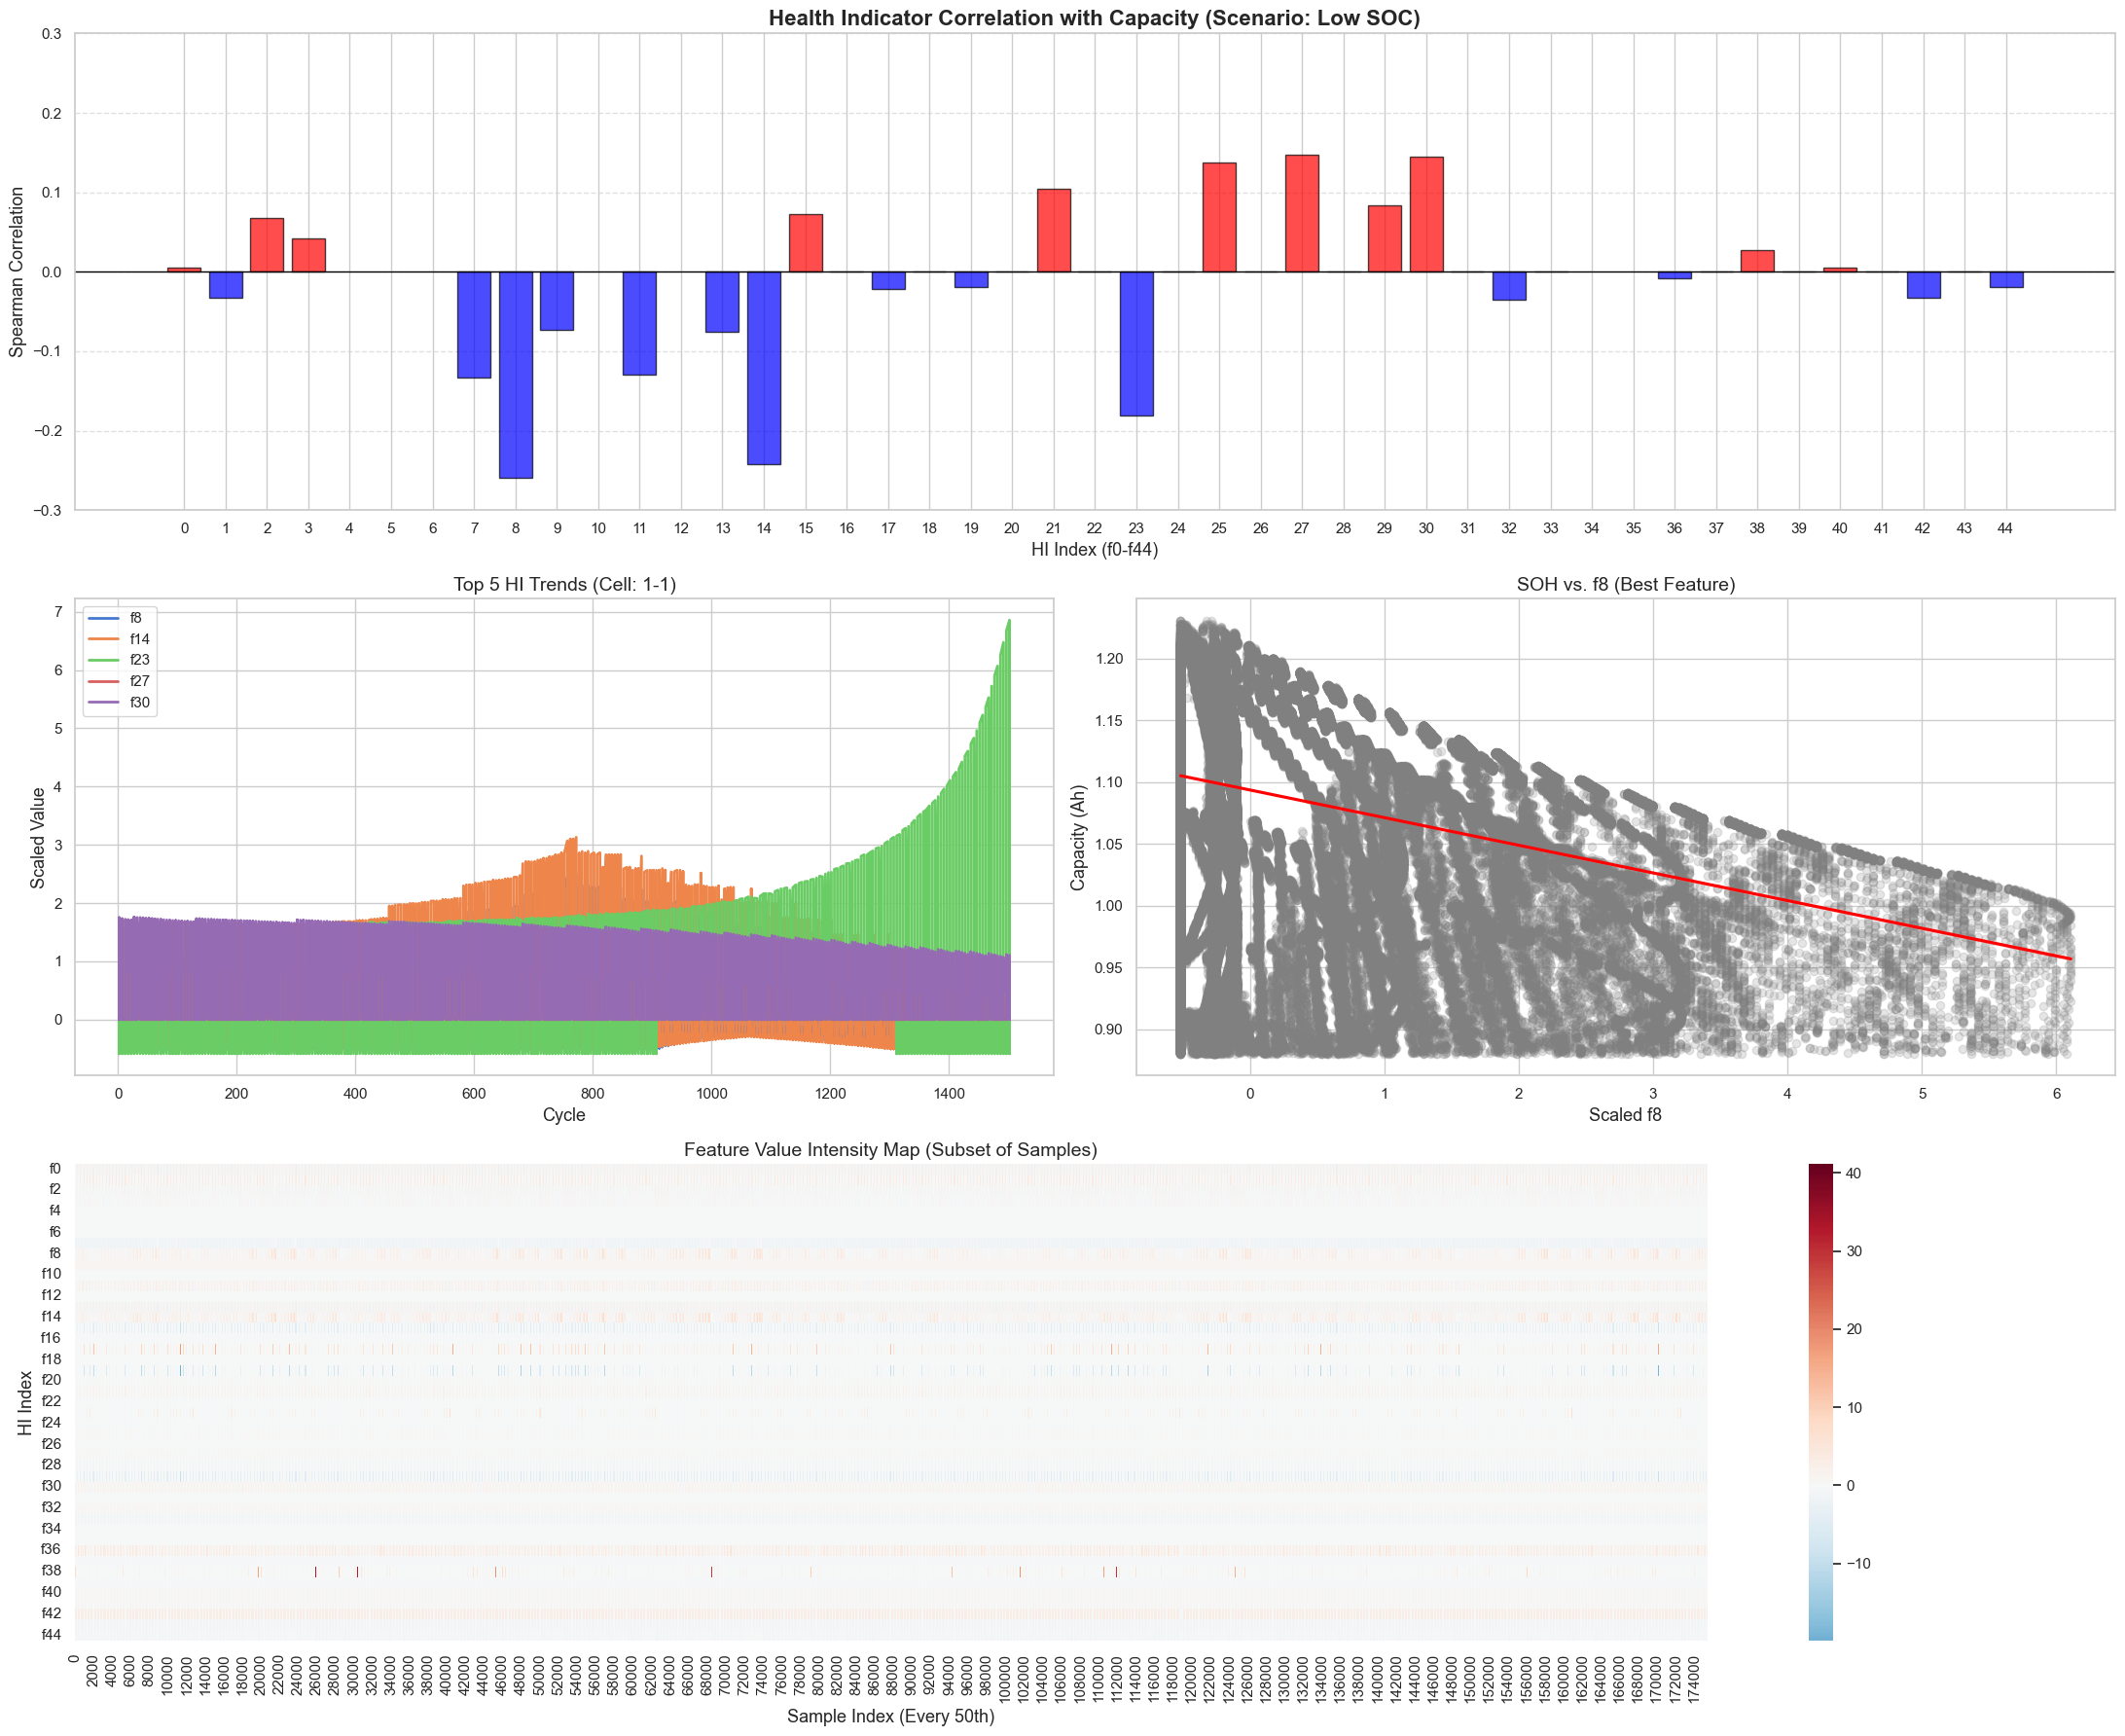

Filtered 292410 samples for soc_label -1 with scaled_x shape: (292410, 48)
=== [Deep Analysis] High SOC Scenario (soc_label: -1) ===
1. Total Segments: 292410
2. Unique Cells  : 77
3. Avg. Capacity : 1.0826 Ah
--------------------------------------------------


c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))



[Top 10 Health Indicators by Correlation with SOH]
     SOH_Correlation      mean       std
f42         0.176699 -0.163315  0.247081
f38         0.150648  0.331625  0.446295
f27         0.136407  0.497428  0.585501
f30         0.134883  0.478929  0.568689
f25         0.134443  0.508121  0.597492
f21         0.101524 -0.064183  0.215969
f8          0.079951  0.013059  1.036030
f7         -0.070901  0.327331  0.838751
f1         -0.065272 -0.500449  0.077346
f9         -0.065225 -0.516914  0.856070


C:\Users\ksshin\AppData\Local\Temp\ipykernel_64684\3394819623.py:59: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3, 1, 1)


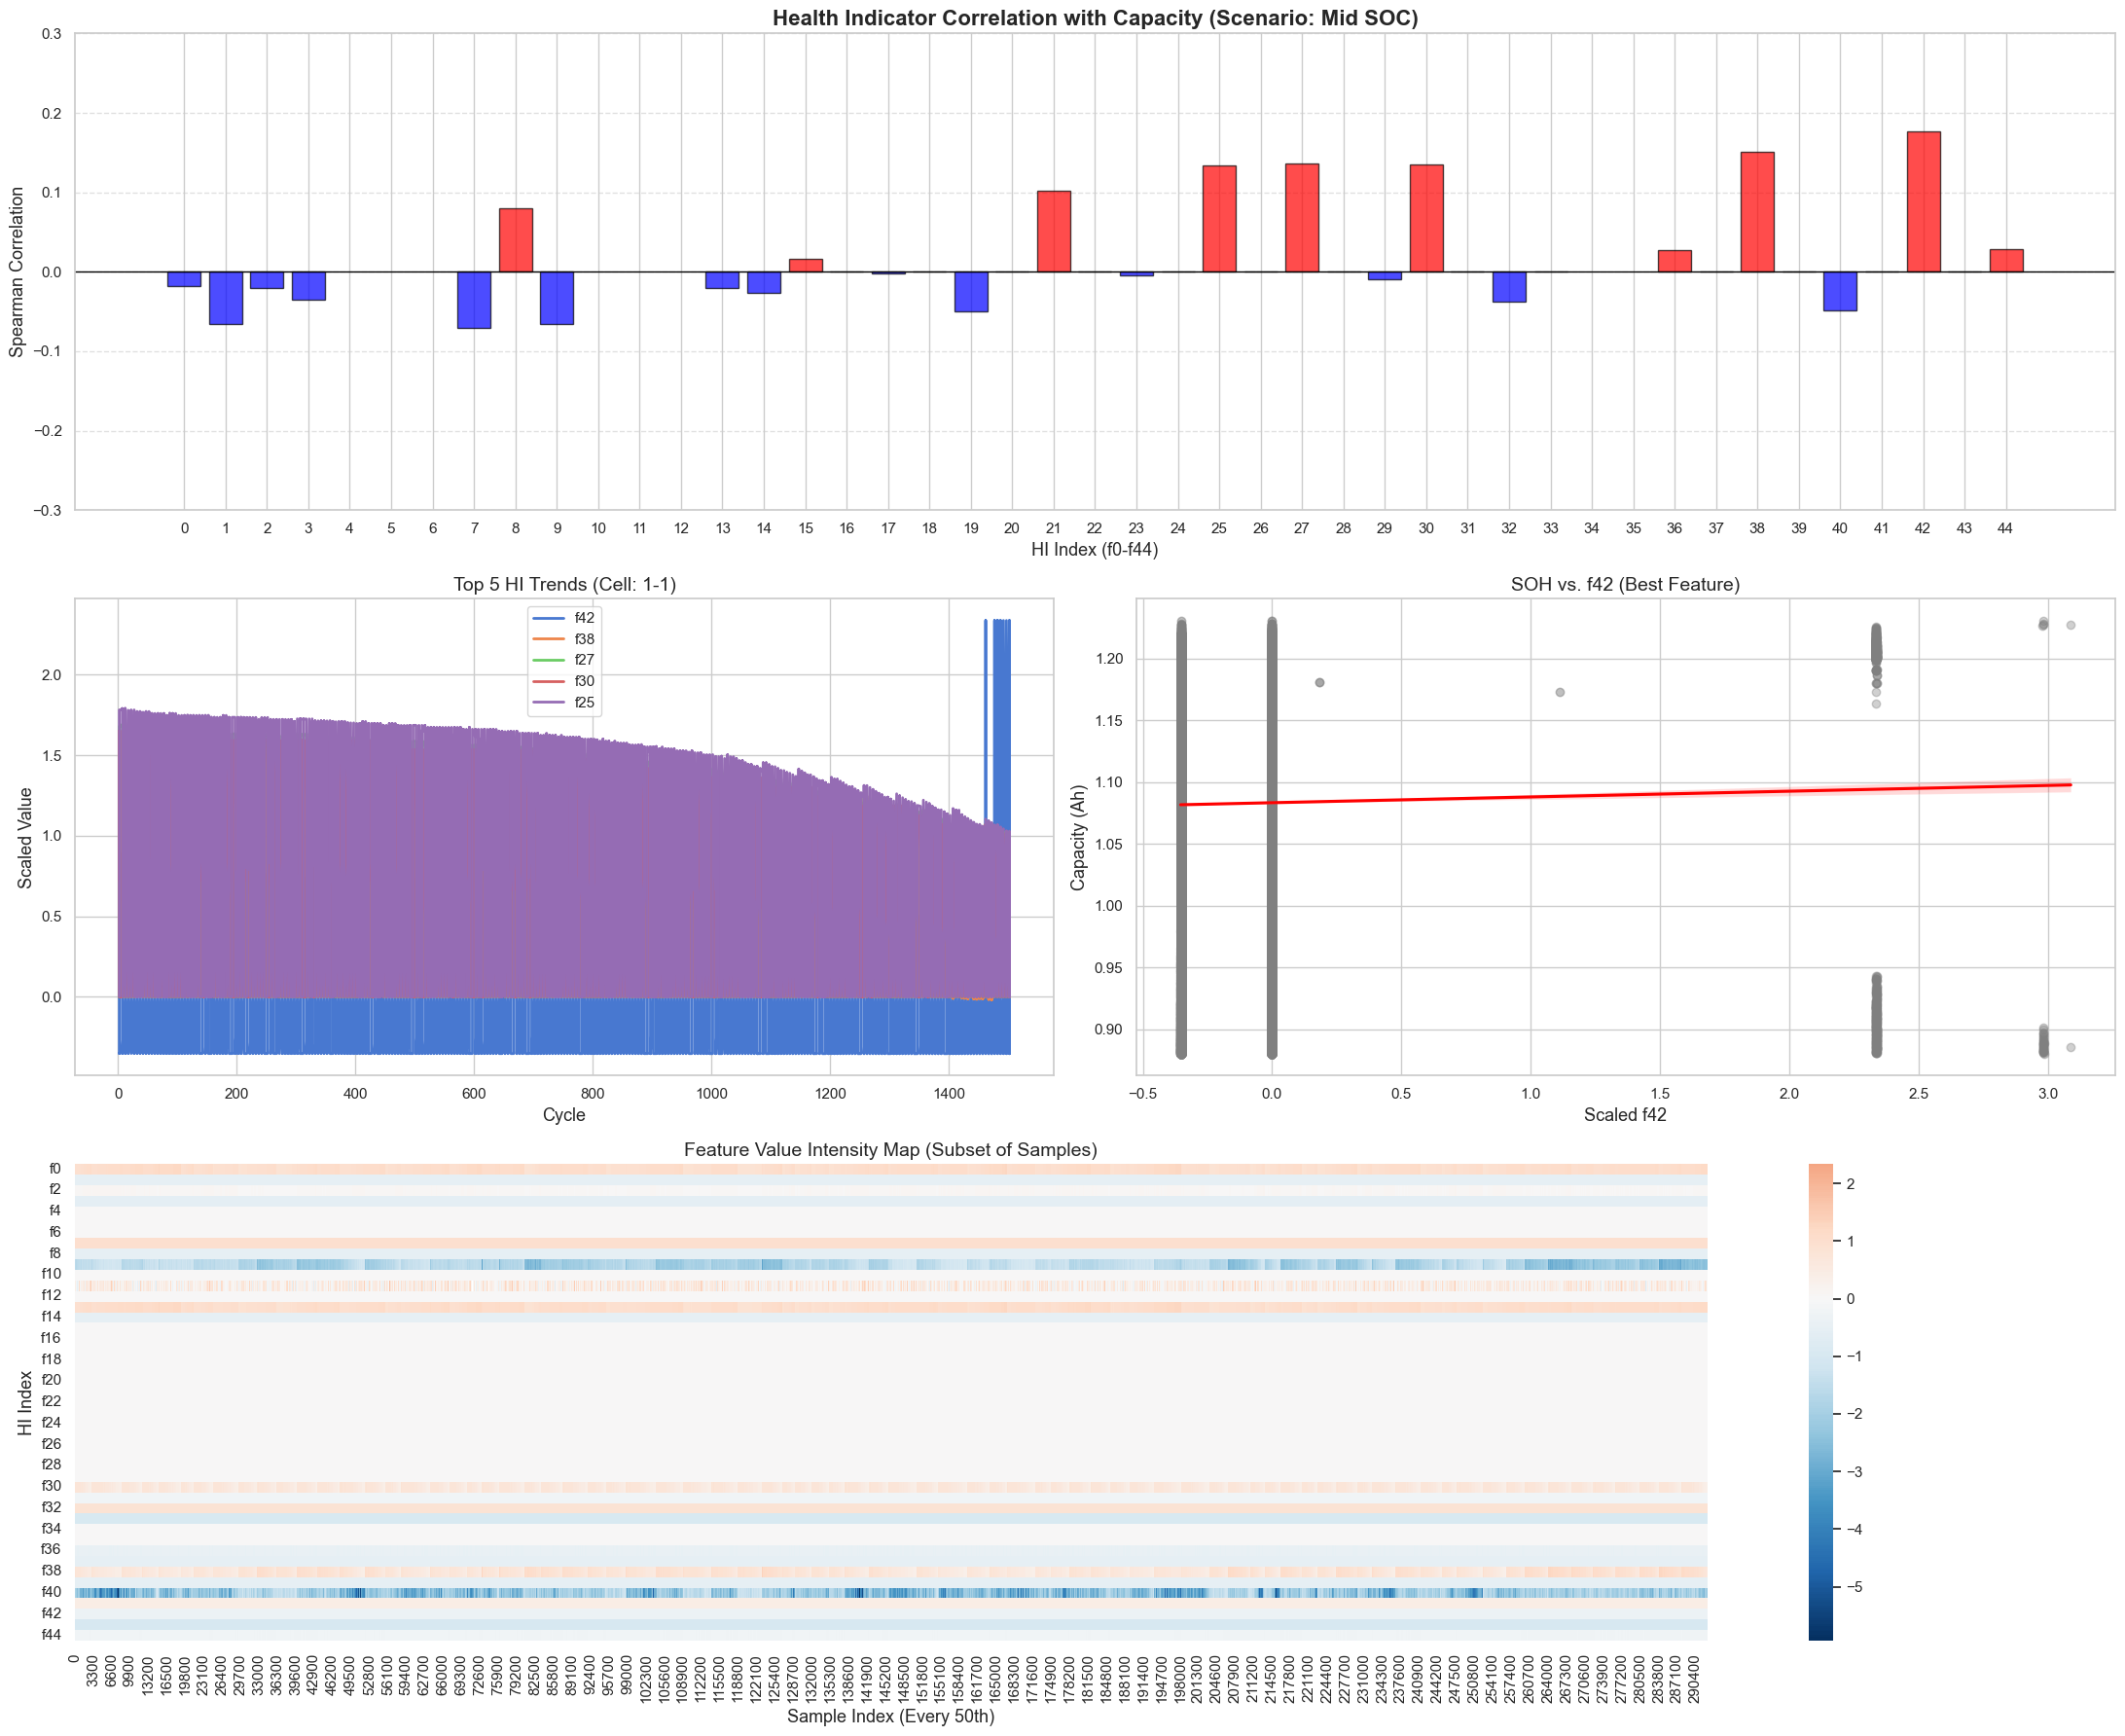

Filtered 175446 samples for soc_label -2 with scaled_x shape: (175446, 48)
=== [Deep Analysis] High SOC Scenario (soc_label: -2) ===
1. Total Segments: 175446
2. Unique Cells  : 77
3. Avg. Capacity : 1.0826 Ah
--------------------------------------------------


c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))



[Top 10 Health Indicators by Correlation with SOH]
     SOH_Correlation      mean       std
f38         0.152626 -0.103856  0.160259
f27         0.146254  0.450990  0.538310
f30         0.145524  0.457317  0.545861
f25         0.142239  0.470578  0.559169
f42         0.118198 -0.173619  0.196007
f8          0.099764 -0.516218  0.002564
f7         -0.098345  0.628862  0.553020
f3          0.091132  0.862615  1.384036
f32         0.084908  0.598918  0.617731
f29         0.081322 -0.061717  0.247700


C:\Users\ksshin\AppData\Local\Temp\ipykernel_64684\3394819623.py:59: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3, 1, 1)


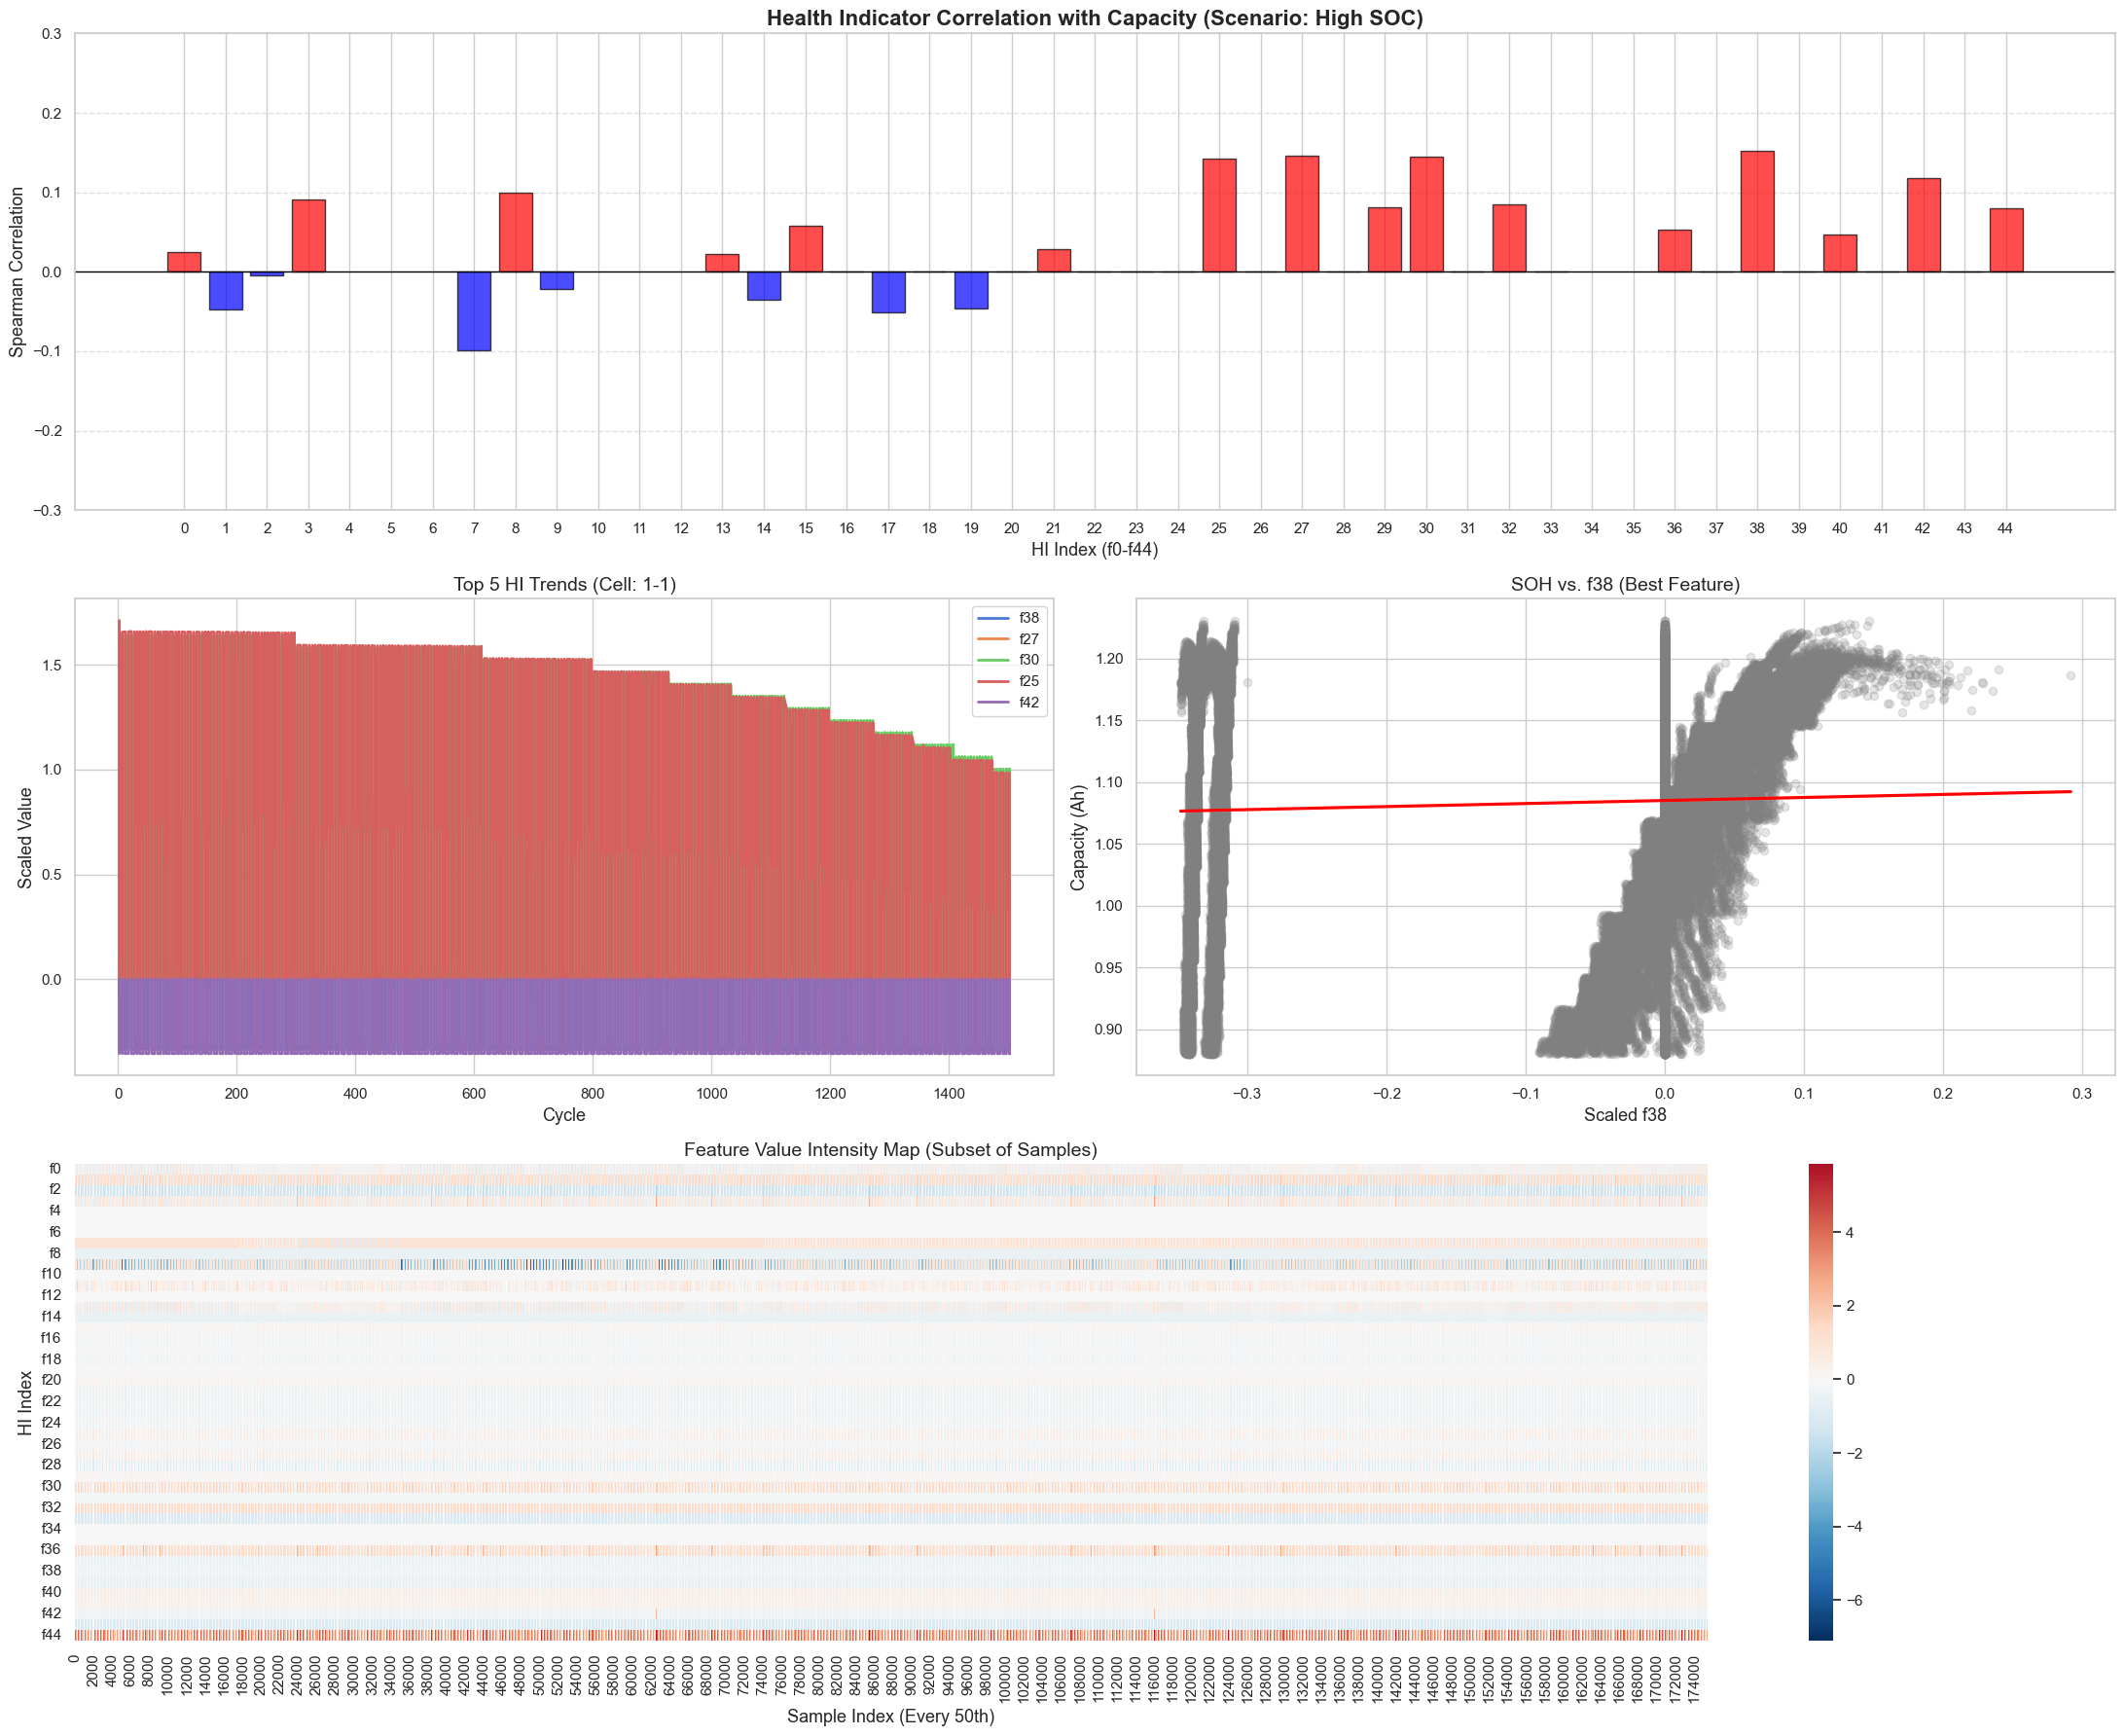

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

def deep_analyze_high_scenario(feature_pool, target_soc=-2):
    """
    특정 SOC 시나리오(기본값: High, -2)에 대해 집중 분석을 수행합니다.
    """
    # 1. 특정 시나리오 데이터 필터링
    high_samples = [s for s in feature_pool if s["soc_label"] == target_soc]
    target_soc_str = { -2: "High SOC", -1: "Mid SOC", 0: "Low SOC" }.get(target_soc, f"SOC {target_soc}")

    # 데이터 형태 샘플로 확인
    data_shape = (len(high_samples), len(high_samples[0]["scaled_x"])) if high_samples else (0, 0)
    print(f"Filtered {len(high_samples)} samples for soc_label {target_soc} with scaled_x shape: {data_shape}")
    
    if not high_samples:
        print(f"No samples found for soc_label {target_soc}")
        return

    # 데이터프레임 변환 (HI 45개 + 메타 정보)
    df = pd.DataFrame([{
        "cell": s["cell"], "cyc": s["cyc"], "mode": s["mode_label"],
        "cap": s["capacity"], "len": s.get("length_p", 0),
        **{f"f{i}": val for i, val in enumerate(s["scaled_x"][:45])}  # 순수 HI 45개만 분석
    } for s in high_samples])

    print(f"=== [Deep Analysis] High SOC Scenario (soc_label: {target_soc}) ===")
    print(f"1. Total Segments: {len(df)}")
    print(f"2. Unique Cells  : {df['cell'].nunique()}")
    print(f"3. Avg. Capacity : {df['cap'].mean():.4f} Ah")
    print("-" * 50)

    # 2. HI 통계치 분석
    hi_cols = [f"f{i}" for i in range(45)]
    hi_stats = df[hi_cols].describe().transpose()[['mean', 'std', 'min', 'max']]

    # 3. HI와 Capacity(SOH) 간의 상관관계 계산 (Spearman 사용 - 비선형 고려)
    correlations = []
    for col in hi_cols:
        corr, _ = spearmanr(df[col], df['cap'])
        correlations.append(corr)

    df_hi_analysis = hi_stats.copy()
    df_hi_analysis['SOH_Correlation'] = correlations
    df_hi_analysis['Abs_Corr'] = np.abs(correlations)

    # 상관관계 상위 10개 피처 출력
    top_10 = df_hi_analysis.sort_values('Abs_Corr', ascending=False).head(10)
    print("\n[Top 10 Health Indicators by Correlation with SOH]")
    print(top_10[['SOH_Correlation', 'mean', 'std']])

    # 4. 시각화 (3-Panel Plot)
    fig = plt.subplots(figsize=(22, 18))

    # (1) Correlation Bar Chart
    plt.subplot(3, 1, 1)
    colors = ['red' if c > 0 else 'blue' for c in correlations]
    plt.bar(range(45), correlations, color=colors, alpha=0.7, edgecolor='black')
    plt.axhline(0, color='black', lw=1)
    plt.title(f"Health Indicator Correlation with Capacity (Scenario: {target_soc_str})", fontsize=16, fontweight='bold')
    plt.xlabel("HI Index (f0-f44)")
    plt.ylabel("Spearman Correlation")
    plt.ylim(-0.3, 0.3)
    plt.xticks(range(0, 45, 1))
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)

    # (2) Top 5 HI Trajectories (Sample Cell)
    plt.subplot(3, 2, 3)
    target_cell = df['cell'].iloc[0]
    df_sample = df[df['cell'] == target_cell].sort_values('cyc')
    top_5_feats = top_10.index[:5]

    for feat in top_5_feats:
        plt.plot(df_sample['cyc'], df_sample[feat], label=feat, lw=2)
    plt.title(f"Top 5 HI Trends (Cell: {target_cell})", fontsize=14)
    plt.xlabel("Cycle")
    plt.ylabel("Scaled Value")
    plt.legend()

    # (3) SOH vs Top Correlation Feature (Scatter)
    plt.subplot(3, 2, 4)
    best_feat = top_10.index[0]
    sns.regplot(data=df, x=best_feat, y='cap',
                scatter_kws={'alpha': 0.2, 'color': 'grey'},
                line_kws={'color': 'red'})
    plt.title(f"SOH vs. {best_feat} (Best Feature)", fontsize=14)
    plt.xlabel(f"Scaled {best_feat}")
    plt.ylabel("Capacity (Ah)")

    # (4) Distribution of Features (Heatmap)
    plt.subplot(3, 1, 3)
    sns.heatmap(df[hi_cols].iloc[::50].transpose(), cmap='RdBu_r', center=0)
    plt.title("Feature Value Intensity Map (Subset of Samples)", fontsize=14)
    plt.xlabel("Sample Index (Every 50th)")
    plt.ylabel("HI Index")

    plt.tight_layout()
    plt.savefig(f"{figure_path}/{DATASET_TYPE}_{target_soc_str}_soc_deep_analysis.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


    return df_hi_analysis


# 분석 실행
if 'batch_feature_pool' in locals() and len(batch_feature_pool) > 0:
    high_analysis_report = deep_analyze_high_scenario(batch_feature_pool, target_soc=0)
    high_analysis_report = deep_analyze_high_scenario(batch_feature_pool, target_soc=-1)
    high_analysis_report = deep_analyze_high_scenario(batch_feature_pool, target_soc=-2)

In [15]:
import pickle
import numpy as np
from pathlib import Path

def inspect_optimized_tensors(data_root="D:/chanminLee/data_store/LFP_SOH_estimation"):
    """
    저장된 optimized_tensors.pkl 파일들을 읽어서 
    전체 샘플 수, 데이터 키(Key), 텐서 차원을 출력합니다.
    """
    root = Path(data_root)
    # 분석할 파일 목록 (mit, hust 등)
    target_files = list(root.glob("*_optimized_tensors.pkl"))
    
    if not target_files:
        print(f"[Error] No files found in {data_root}")
        return

    for file_path in target_files:
        print(f"\n{'='*60}")
        print(f" FILE: {file_path.name}")
        print(f"{'='*60}")

        try:
            with open(file_path, "rb") as f:
                data_pool = pickle.load(f)

            num_samples = len(data_pool)
            print(f"1. Total Sample Count: {num_samples:,}")

            if num_samples > 0:
                sample = data_pool[0]
                print(f"2. Data Keys: {list(sample.keys())}")

                print(f"3. Component Shapes & Types:")
                # 입력 피처(x) 확인
                if 'x' in sample:
                    x_val = sample['x']
                    print(f"   - [x] Input Features : {x_val.shape} (Dtype: {x_val.dtype})")

                    # 48차원 여부 체크 (45 HI + 3 Meta)
                    if x_val.shape[0] == 48:
                        print("     >> Status: 48D (Scenario A Meta-Injected) - CORRECT")
                    else:
                        print(f"     >> Status: {x_val.shape[0]}D - Needs reprocessing for 48D")

                # 타겟 값 확인
                if 'y' in sample:
                    print(f"   - [y] RUL Label      : Scalar ({type(sample['y']).__name__})")
                if 'capacity' in sample:
                    print(f"   - [capacity] SOH Label: Scalar ({type(sample['capacity']).__name__})")

                # 메타 데이터 예시 출력
                print(f"4. Sample Value Preview (Index 0):")
                print(f"   - Cell ID: {sample.get('cell')}, Cycle: {sample.get('cyc')}")
                print(f"   - Mode: {'Charge' if sample.get('mode_label')==1 else 'Discharge'}")
                if x_val.shape[0] >= 48:
                    print(f"   - Injected Meta (Last 3): {x_val[-3:]} (SOC, Mode, Length)")

        except Exception as e:
            print(f"[Error] Failed to read {file_path.name}: {e}")

# 점검 실행
inspect_optimized_tensors()


 FILE: hust_optimized_tensors.pkl
1. Total Sample Count: 643,302
2. Data Keys: ['cell', 'cyc', 'x', 'soc_label', 'mode_label', 'length_p', 'y', 'capacity']
3. Component Shapes & Types:
   - [x] Input Features : (48,) (Dtype: float64)
     >> Status: 48D (Scenario A Meta-Injected) - CORRECT
   - [y] RUL Label      : Scalar (float)
   - [capacity] SOH Label: Scalar (float)
4. Sample Value Preview (Index 0):
   - Cell ID: 1-1, Cycle: 2
   - Mode: Charge
   - Injected Meta (Last 3): [-2.   1.   0.2] (SOC, Mode, Length)

 FILE: mit_optimized_tensors.pkl
1. Total Sample Count: 503,535
2. Data Keys: ['cell', 'cyc', 'x', 'soc_label', 'mode_label', 'length_p', 'y', 'capacity']
3. Component Shapes & Types:
   - [x] Input Features : (48,) (Dtype: float64)
     >> Status: 48D (Scenario A Meta-Injected) - CORRECT
   - [y] RUL Label      : Scalar (float)
   - [capacity] SOH Label: Scalar (float)
4. Sample Value Preview (Index 0):
   - Cell ID: b1c0, Cycle: 2
   - Mode: Charge
   - Injected Meta (La

## Phase 6: Comprehensive Pipeline Diagnostics
Consolidated analysis of optimized tensors and intermediate sliced segments.

Analyzing Batches:   0%|          | 0/10 [00:00<?, ?it/s]

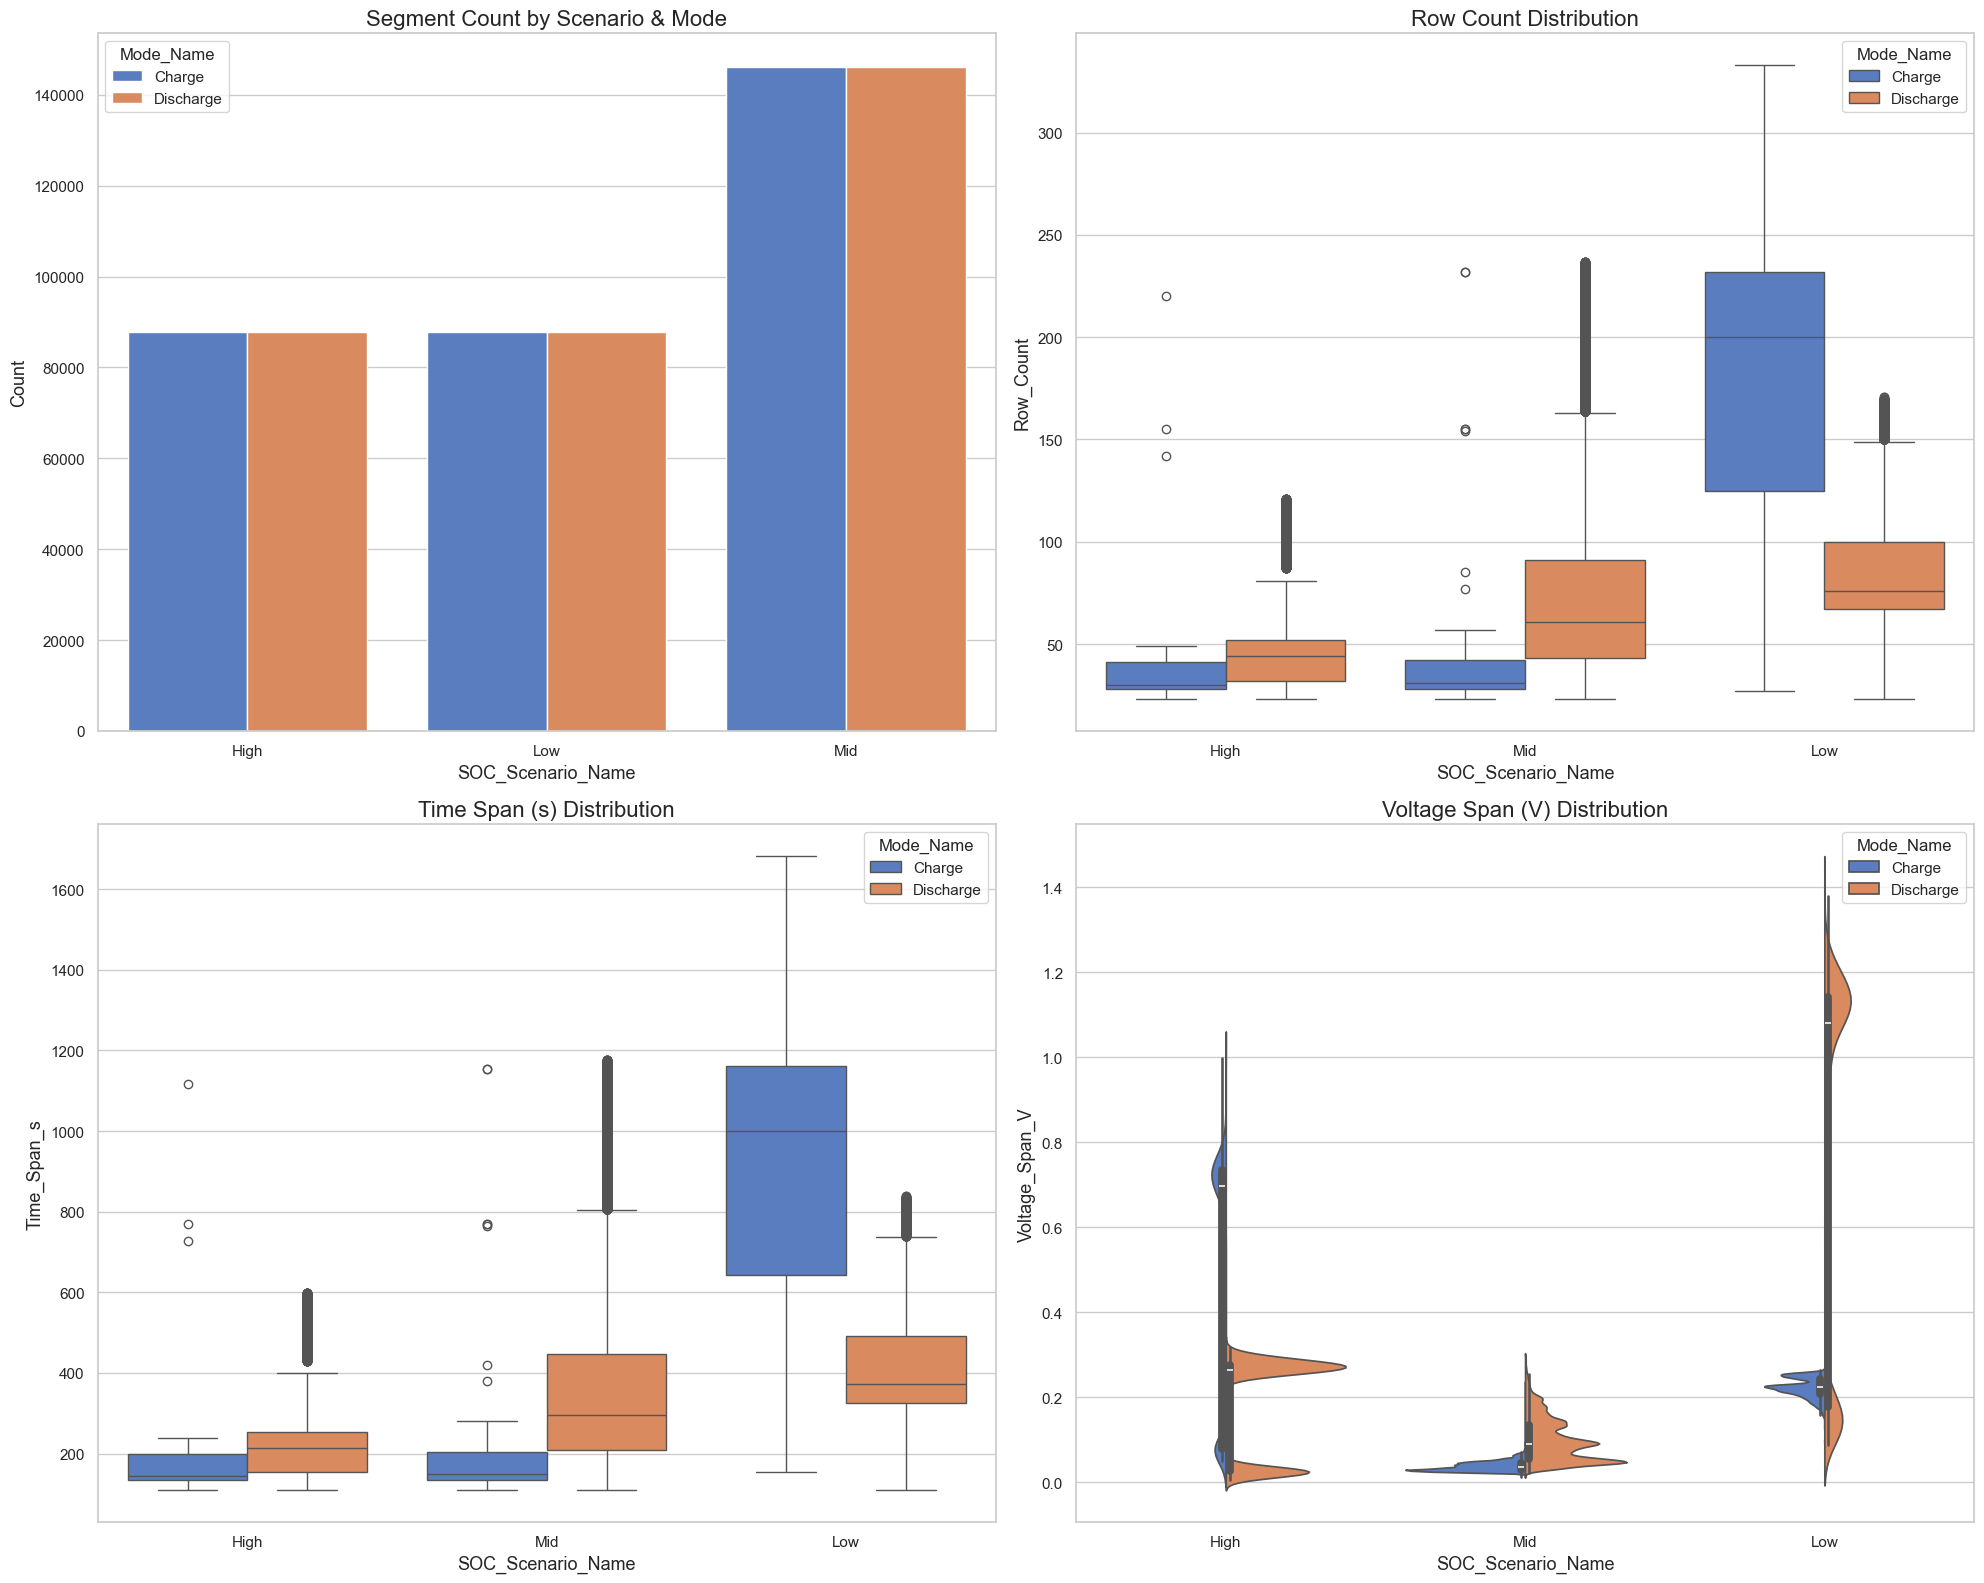


[Success] Comprehensive report saved to: c:\Users\ksshin\Desktop\ChanminLee\LFP_SOH_prediction\outputs\reports\hust_comprehensive_analysis.txt
 COMPREHENSIVE DATA ANALYSIS REPORT: HUST
 Date: 2026-05-13

[Part A] Optimized Tensor Inspection
1. Total Sample Count: 643,302
2. Data Keys: ['cell', 'cyc', 'x', 'soc_label', 'mode_label', 'length_p', 'y', 'capacity']
3. Feature Shape: (48,) -> CORRECT (48D)
4. Sample Metadata: Cell=1-1, Cyc=2, Mode=Charge


[Part B] Sliced Segment Statistics
Mode_Name SOC_Scenario_Name  Count   Row_Mean  Time_Mean_s  Volt_Mean_V
   Charge              High  87723  33.416367   161.413895     0.509712
   Charge               Low  87723 184.555977   933.257385     0.222984
   Charge               Mid 146205  34.032188   165.170517     0.038264
Discharge              High  87723  46.047536   224.568588     0.190661
Discharge               Low  87723  82.096999   402.160400     0.792578
Discharge               Mid 146205  72.699347   355.885803     0.100273

[Suc

In [16]:
def run_comprehensive_analysis(dataset_type=DATASET_TYPE, data_root=PROCESSED_DATA_ROOT):
    """
    [Unified Analysis] Tensor Inspection + Segment Statistics (Fixed Visualization)
    """
    import pickle
    from pathlib import Path
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tqdm.auto import tqdm
    from datetime import date
    
    report_lines = []
    report_lines.append("="*80)
    report_lines.append(f" COMPREHENSIVE DATA ANALYSIS REPORT: {dataset_type.upper()}")
    report_lines.append(f" Date: {date.today().strftime('%Y-%m-%d')}")
    report_lines.append("="*80 + "\n")

    # --- Part A: Tensor Inspection ---
    tensor_path = Path(data_root) / f"{dataset_type}_optimized_tensors.pkl"
    report_lines.append("[Part A] Optimized Tensor Inspection")
    if not tensor_path.exists():
        report_lines.append(f"[Error] Tensor file not found: {tensor_path}")
    else:
        with open(tensor_path, "rb") as f: data_pool = pickle.load(f)
        num_samples = len(data_pool)
        report_lines.append(f"1. Total Sample Count: {num_samples:,}")
        if num_samples > 0:
            sample = data_pool[0]
            report_lines.append(f"2. Data Keys: {list(sample.keys())}")
            if 'x' in sample:
                x_shape = sample['x'].shape
                status = "CORRECT (48D)" if x_shape[0] == 48 else f"INCORRECT ({x_shape[0]}D)"
                report_lines.append(f"3. Feature Shape: {x_shape} -> {status}")
            report_lines.append(f"4. Sample Metadata: Cell={sample.get('cell')}, Cyc={sample.get('cyc')}, Mode={'Charge' if sample.get('mode_label')==1 else 'Discharge'}")
        del data_pool
    report_lines.append("\n")

    # --- Part B: Sliced Chunks Statistics ---
    cache_dir = Path(data_root) / f"{dataset_type}_sliced_chunks"
    batch_files = sorted(cache_dir.glob("batch_*.pkl"))
    report_lines.append("[Part B] Sliced Segment Statistics")
    if not batch_files:
        report_lines.append(f"[Error] No sliced batch files found in {cache_dir}")
    else:
        stats_list = []
        for bf in tqdm(batch_files, desc="Analyzing Batches"):
            with open(bf, "rb") as f: batch_data = pickle.load(f)
            segments = batch_data.get('segments', [])
            for item in segments:
                df = item.get('df')
                if df is None or df.empty: continue
                # Handle variable column names (t vs Time (s), V vs Voltage (V))
                t_col = 't' if 't' in df.columns else 'Time (s)'
                v_col = 'V' if 'V' in df.columns else 'Voltage (V)'
                
                stats_list.append({
                    'SOC_Scenario': item.get('soc_label'),
                    'Mode': item.get('mode_label'),
                    'Window_Size': item.get('length_p'),
                    'Row_Count': len(df),
                    'Time_Span_s': (df[t_col].max() - df[t_col].min()) if t_col in df.columns else np.nan,
                    'Voltage_Span_V': (df[v_col].max() - df[v_col].min()) if v_col in df.columns else np.nan
                })
        df_stats = pd.DataFrame(stats_list)
        df_stats['SOC_Scenario_Name'] = df_stats['SOC_Scenario'].map({-2: 'High', -1: 'Mid', 0: 'Low'})
        df_stats['Mode_Name'] = df_stats['Mode'].map({1: 'Charge', 0: 'Discharge'})
        
        grouped = df_stats.groupby(['Mode_Name', 'SOC_Scenario_Name']).agg(
            Count=('Row_Count', 'count'), Row_Mean=('Row_Count', 'mean'), Time_Mean_s=('Time_Span_s', 'mean'), Volt_Mean_V=('Voltage_Span_V', 'mean')
        ).reset_index()
        report_lines.append(grouped.to_string(index=False))
        
        # --- Visualization (Simplified to avoid boxprops error) ---
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        
        # 1. Barplot
        sns.barplot(data=grouped, x='SOC_Scenario_Name', y='Count', hue='Mode_Name', ax=axes[0,0])
        axes[0,0].set_title("Segment Count by Scenario & Mode")
        
        # 2. Row Count Boxplot
        sns.boxplot(data=df_stats, x='SOC_Scenario_Name', y='Row_Count', hue='Mode_Name', ax=axes[0,1])
        axes[0,1].set_title("Row Count Distribution")
        
        # 3. Time Span Boxplot
        sns.boxplot(data=df_stats, x='SOC_Scenario_Name', y='Time_Span_s', hue='Mode_Name', ax=axes[1,0])
        axes[1,0].set_title("Time Span (s) Distribution")
        
        # 4. Voltage Span Violinplot
        sns.violinplot(data=df_stats, x='SOC_Scenario_Name', y='Voltage_Span_V', hue='Mode_Name', split=True, ax=axes[1,1])
        axes[1,1].set_title("Voltage Span (V) Distribution")
        
        plt.tight_layout()
        vis_path = FIGURE_ROOT / f"{dataset_type}_comprehensive_analysis.png"
        plt.savefig(vis_path, dpi=300, bbox_inches='tight')
        plt.show()
        report_lines.append(f"\n[Success] Visualization saved to: {vis_path}")

    # --- Save Report ---
    report_dir = PROJECT_ROOT / "outputs" / "reports"
    report_dir.mkdir(parents=True, exist_ok=True)
    report_path = report_dir / f"{dataset_type}_comprehensive_analysis.txt"
    with open(report_path, "w", encoding="utf-8") as f: f.write("\n".join(report_lines))
    print(f"\n[Success] Comprehensive report saved to: {report_path}")
    print("\n".join(report_lines))

run_comprehensive_analysis()